
# BayesMMRL Mechanism Diagnosis v3 — fixed4 patched full

这版基于仓库里的 `BayesMMRL_mechanism_diagnosis_v3_complete_results_only_fixed4.ipynb` 思路重建。

修复点：

1. 保留 fixed4 的实现路线：
   - `from core.config import setup_cfg`
   - `importlib.import_module("trainers.refactor_runner")`
   - `trainer="RefactorRunner"`
   - `method="BayesMMRL"` / `method="MMRL"` 作为方法配置，不作为 Dassl trainer registry 名称
2. `infer_case_metadata()` 不再硬找 `output_refactor`，改为找稳定锚点：
   - `FS/fewshot_train/<dataset>/shots_x/<backbone>/<tag>/seedx`
3. 支持两类目录：
   - `output_refactor/...`
   - `output_sweeps/.../confirm_stage/...`
4. 对 `output_sweeps` 优先从 `log.txt` 读取训练时的 `opts`，保留 `BAYES_MMRL.*` sweep 超参。
5. 权重路径仍然保持 `.../ViT-B-16/...`；但 `cfg.MODEL.BACKBONE.NAME` 强制使用 `ViT-B/16`。
6. 保留完整分析流程：
   - cfg/state_dict/posterior audit
   - deterministic forward
   - MC forward
   - case metrics
   - paired outcome
   - posterior/uncertainty/branch/fusion 可视化
   - CSV 和 PNG 保存


## 0. 使用说明

In [ ]:

from pathlib import Path

# ======== 修改这里 ========
REPO_ROOT = Path("/root/autodl-tmp/MMRL").expanduser().resolve()
DATA_ROOT = REPO_ROOT / "DATASETS"

CASES = [
    {
        "name": "MMRL_caltech101_16shot_seed1",
        "case_root": REPO_ROOT / "output_sweeps/bayes_mmrl_rep_tokens/coarse3/confirm_stage/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/rep_zero_sig-diagonal_pstd-1.0_kl-5e-2/seed1",
    },
    {
        "name": "BayesMMRL_caltech101_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
]

SPLIT = "test"          # "test" or "val"
MAX_BATCHES = None      # debug 时可设为 2 / 5
BAYES_N_MC = 20         # 分析用 MC samples 数，不影响训练
DEVICE = None           # None 表示自动用 trainer.device
SAVE_DIR = REPO_ROOT / "analysis_outputs" / "bayes_mmrl_mechanism_v2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

assert REPO_ROOT.exists(), f"REPO_ROOT 不存在: {REPO_ROOT}"
assert DATA_ROOT.exists(), f"DATA_ROOT 不存在: {DATA_ROOT}"
for case in CASES:
    assert Path(case["case_root"]).exists(), f"case_root 不存在: {case['case_root']}"

print("REPO_ROOT =", REPO_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("SAVE_DIR  =", SAVE_DIR)
print("CASES     =", len(CASES))

for case in CASES:
    print("\nCASE:", case["name"])
    print("  case_root =", case["case_root"])


REPO_ROOT = /root/autodl-tmp/MMRL
DATA_ROOT = /root/autodl-tmp/MMRL/DATASETS
SAVE_DIR  = /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2
CASES     = 2

CASE: MMRL_caltech101_16shot_seed1
  case_root = /root/autodl-tmp/MMRL/output_sweeps/bayes_mmrl_rep_tokens/coarse3/confirm_stage/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/rep_zero_sig-diagonal_pstd-1.0_kl-5e-2/seed1

CASE: BayesMMRL_caltech101_16shot_seed1
  case_root = /root/autodl-tmp/MMRL/output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1


## 1. Imports 与仓库初始化

In [2]:

import os
import sys
import math
import json
import ast
import importlib
from types import SimpleNamespace
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from core.config import setup_cfg
from dassl.engine import build_trainer
from core.utils import import_optional_modules

# 按仓库原来的 optional imports
import_optional_modules([
    "datasets.oxford_pets", "datasets.oxford_flowers", "datasets.fgvc_aircraft",
    "datasets.dtd", "datasets.eurosat", "datasets.stanford_cars", "datasets.food101",
    "datasets.sun397", "datasets.caltech101", "datasets.ucf101", "datasets.imagenet",
    "datasets.imagenetv2", "datasets.imagenet_sketch", "datasets.imagenet_a", "datasets.imagenet_r",
])

# fixed4 的核心实现路线：复用 RefactorRunner
importlib.import_module("trainers.refactor_runner")

print("torch =", torch.__version__)
print("cuda available =", torch.cuda.is_available())


torch = 2.11.0+cu128
cuda available = True


## 2. 从 `case_root` 重建 trainer 并加载 checkpoint

In [3]:

METHOD_CFG_MAP = {
    "MMRL": "configs/methods/mmrl.yaml",
    "MMRLMix": "configs/methods/mmrl_mix.yaml",
    "MMRLpp": "configs/methods/mmrlpp.yaml",
    "MMRLPP": "configs/methods/mmrlpp.yaml",
    "BayesMMRL": "configs/methods/bayesmmrl.yaml",
    "ClipAdapters": "configs/methods/clip_adapters.yaml",
    "ClipADAPTER": "configs/methods/clip_adapters.yaml",
}

PROTOCOL_CFG_MAP = {
    "B2N": "configs/protocols/b2n.yaml",
    "FS": "configs/protocols/fs.yaml",
    "CD": "configs/protocols/cd.yaml",
}

PROTOCOL_TO_SUBSAMPLE = {
    "B2N": "base",
    "FS": "all",
    "CD": "all",
}

def decode_backbone_from_dir(token: str) -> str:
    token = str(token)
    mapping = {
        "ViT-B-16": "ViT-B/16",
        "ViT-B-32": "ViT-B/32",
        "ViT-L-14": "ViT-L/14",
        "ViT-L-14-336px": "ViT-L/14@336px",
    }
    if token in mapping:
        return mapping[token]
    if token.startswith("ViT-") and token.count("-") >= 2:
        head, patch = token.rsplit("-", 1)
        return f"{head}/{patch}"
    return token

def encode_backbone_to_dir(name: str) -> str:
    name = str(name)
    mapping = {
        "ViT-B/16": "ViT-B-16",
        "ViT-B/32": "ViT-B-32",
        "ViT-L/14": "ViT-L-14",
        "ViT-L/14@336px": "ViT-L-14-336px",
    }
    return mapping.get(name, name)

def parse_log_txt(case_root: Path):
    """
    从训练日志里读取真实 args。
    对 output_sweeps 很重要，因为 sweep 的 BAYES_MMRL.* 超参通常只在 log opts 里完整出现。
    """
    case_root = Path(case_root)
    log_paths = [case_root / "log.txt", case_root / "run.log"]
    log_path = next((p for p in log_paths if p.exists()), None)

    out = {
        "log_path": str(log_path) if log_path is not None else "",
        "method": None,
        "trainer": None,
        "protocol": None,
        "opts": None,
        "dataset_config_file": None,
        "method_config_file": None,
        "protocol_config_file": None,
        "runtime_config_file": None,
        "output_dir": None,
        "root": None,
    }
    if log_path is None:
        return out

    txt = log_path.read_text(errors="ignore")
    for raw in txt.splitlines():
        line = raw.strip()

        if line.startswith("method:"):
            out["method"] = line.split(":", 1)[1].strip()
        elif line.startswith("trainer:"):
            out["trainer"] = line.split(":", 1)[1].strip()
        elif line.startswith("protocol:"):
            out["protocol"] = line.split(":", 1)[1].strip()
        elif line.startswith("dataset_config_file:"):
            out["dataset_config_file"] = line.split(":", 1)[1].strip()
        elif line.startswith("method_config_file:"):
            out["method_config_file"] = line.split(":", 1)[1].strip()
        elif line.startswith("protocol_config_file:"):
            out["protocol_config_file"] = line.split(":", 1)[1].strip()
        elif line.startswith("runtime_config_file:"):
            out["runtime_config_file"] = line.split(":", 1)[1].strip()
        elif line.startswith("output_dir:"):
            out["output_dir"] = line.split(":", 1)[1].strip()
        elif line.startswith("root:"):
            out["root"] = line.split(":", 1)[1].strip()
        elif line.startswith("opts:"):
            s = line.split(":", 1)[1].strip()
            try:
                val = ast.literal_eval(s)
                if isinstance(val, list):
                    out["opts"] = [str(x) for x in val]
            except Exception as e:
                print("[WARN] failed to parse opts in", log_path, ":", repr(e))

    return out

def set_or_append_opt(opts, key, value):
    opts = [] if opts is None else list(opts)
    key = str(key)
    value = str(value)
    if key in opts:
        idx = opts.index(key)
        if idx + 1 >= len(opts):
            raise ValueError(f"opts 中 {key} 后面没有 value")
        opts[idx + 1] = value
    else:
        opts.extend([key, value])
    return opts

def infer_case_metadata(case_root: Path):
    """
    fixed4 原逻辑只支持 output_refactor:
        output_refactor/<method>/<protocol>/<phase>/<dataset>/shots_x/<backbone>/<tag>/seedx

    这里改为支持任意前缀，只找稳定锚点：
        <method>/FS/fewshot_train/<dataset>/shots_x/<backbone>/<tag>/seedx

    因此支持:
        output_refactor/...
        output_sweeps/.../confirm_stage/...
    """
    case_root = Path(case_root).resolve()
    parts = case_root.parts

    anchors = [
        i for i, p in enumerate(parts)
        if p in PROTOCOL_CFG_MAP and i + 1 < len(parts) and parts[i + 1] in ["fewshot_train", "base_to_new_train", "cross_dataset_train"]
    ]
    if not anchors:
        raise ValueError(f"无法从路径中找到 protocol/phase 锚点: {case_root}")

    idx = anchors[-1]

    method_from_path = parts[idx - 1]
    protocol = parts[idx]
    phase = parts[idx + 1]
    dataset = parts[idx + 2]
    shots_str = parts[idx + 3]
    backbone_token = parts[idx + 4]
    backbone = decode_backbone_from_dir(backbone_token)
    tag = parts[idx + 5]
    seed_dir = parts[idx + 6]

    if not shots_str.startswith("shots_"):
        raise ValueError(f"shots 字段异常: {shots_str}, path={case_root}")
    if not seed_dir.startswith("seed"):
        raise ValueError(f"seed 字段异常: {seed_dir}, path={case_root}")

    shots = int(shots_str.split("_", 1)[1])
    seed = int(seed_dir.replace("seed", ""))

    if "output_refactor" in parts:
        output_family = "output_refactor"
    elif "output_sweeps" in parts:
        output_family = "output_sweeps"
    else:
        output_family = "unknown"

    log_info = parse_log_txt(case_root)

    # 训练时真实 method 优先来自 log；没有 log 时用路径 method
    method = log_info.get("method") or method_from_path

    return {
        "method": method,
        "method_from_path": method_from_path,
        "protocol": protocol,
        "phase": phase,
        "dataset": dataset,
        "shots": shots,
        "backbone": backbone,
        "backbone_token": backbone_token,
        "tag": tag,
        "seed": seed,
        "case_root": case_root,
        "output_family": output_family,
        "log_info": log_info,
    }

def make_args_from_case(meta):
    method = meta["method"]
    protocol = meta["protocol"]
    dataset = meta["dataset"]
    shots = meta["shots"]
    backbone = meta["backbone"]
    seed = meta["seed"]
    case_root = meta["case_root"]
    log_info = meta.get("log_info", {}) or {}

    method_cfg = log_info.get("method_config_file") or METHOD_CFG_MAP[method]
    protocol_cfg = log_info.get("protocol_config_file") or PROTOCOL_CFG_MAP[protocol]
    subsample = PROTOCOL_TO_SUBSAMPLE[protocol]

    # fixed4 的关键：trainer 是 RefactorRunner，不是 BayesMMRL。
    trainer_name = log_info.get("trainer") or "RefactorRunner"

    # 对 output_sweeps，保留训练日志中的 BAYES_MMRL.* opts
    opts = list(log_info.get("opts") or [])
    opts = set_or_append_opt(opts, "DATASET.NUM_SHOTS", shots)
    opts = set_or_append_opt(opts, "DATASET.SUBSAMPLE_CLASSES", subsample)
    opts = set_or_append_opt(opts, "MODEL.BACKBONE.NAME", backbone)

    # 这些不要写成相对 output_dir，否则 notebook 当前 cwd 改变时可能错。
    output_dir = str(case_root)

    args = SimpleNamespace(
        root=str(DATA_ROOT),
        output_dir=output_dir,
        dataset_config_file=log_info.get("dataset_config_file") or f"configs/datasets/{dataset}.yaml",
        method_config_file=method_cfg,
        protocol_config_file=protocol_cfg,
        runtime_config_file=log_info.get("runtime_config_file") or "configs/runtime/default.yaml",
        exp_config="",
        method=method,
        protocol=protocol,
        exec_mode="online",
        seed=seed,
        trainer=trainer_name,
        eval_only=True,
        model_dir=str(case_root),
        load_epoch=None,
        no_train=True,
        opts=opts,
    )
    return args

def debug_case_cfg(meta, args, cfg):
    print("\n[DEBUG case]")
    print("name                    =", meta.get("name"))
    print("case_root               =", meta["case_root"])
    print("output_family           =", meta["output_family"])
    print("method_from_path        =", meta["method_from_path"])
    print("method                  =", meta["method"])
    print("trainer                 =", args.trainer)
    print("protocol                =", meta["protocol"])
    print("dataset                 =", meta["dataset"])
    print("shots                   =", meta["shots"])
    print("backbone_token(path)    =", meta["backbone_token"])
    print("backbone(cfg)           =", meta["backbone"])
    print("tag                     =", meta["tag"])
    print("seed                    =", meta["seed"])
    print("log_path                =", meta.get("log_info", {}).get("log_path") or "<none>")
    print("method_config_file      =", args.method_config_file)
    print("protocol_config_file    =", args.protocol_config_file)
    print("runtime_config_file     =", args.runtime_config_file)
    print("cfg.TRAINER.NAME        =", cfg.TRAINER.NAME)
    print("cfg.METHOD.NAME         =", cfg.METHOD.NAME if hasattr(cfg, "METHOD") and hasattr(cfg.METHOD, "NAME") else "<no METHOD.NAME>")
    print("cfg.MODEL.BACKBONE.NAME =", cfg.MODEL.BACKBONE.NAME)

    if cfg.TRAINER.NAME != "RefactorRunner":
        raise AssertionError(f"cfg.TRAINER.NAME 应为 RefactorRunner，当前是 {cfg.TRAINER.NAME}")

    if cfg.MODEL.BACKBONE.NAME != meta["backbone"]:
        raise AssertionError(f"backbone 没进入 cfg: cfg={cfg.MODEL.BACKBONE.NAME}, meta={meta['backbone']}")

def build_trainer_for_case(case):
    case_root = Path(case["case_root"]).resolve()
    meta = infer_case_metadata(case_root)
    meta["name"] = case.get("name", case_root.name)

    args = make_args_from_case(meta)
    cfg = setup_cfg(args)
    debug_case_cfg(meta, args, cfg)

    trainer = build_trainer(cfg)
    trainer.load_model(str(case_root))
    trainer.set_model_mode("eval")
    return trainer, meta


## 3. 通用指标函数

In [4]:

def safe_to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().float().cpu()
    return x

def entropy_from_probs(p, eps=1e-12):
    p = p.clamp_min(eps)
    return -(p * p.log()).sum(dim=-1)

def top1_conf_margin_from_logits(logits):
    probs = torch.softmax(logits, dim=-1)
    conf, pred = probs.max(dim=-1)
    top2 = torch.topk(probs, k=min(2, probs.shape[-1]), dim=-1).values
    margin = top2[:, 0] if top2.shape[-1] == 1 else top2[:, 0] - top2[:, 1]
    ent = entropy_from_probs(probs)
    return pred, conf, margin, ent, probs

def nll_from_logits(logits, labels):
    return F.cross_entropy(logits, labels, reduction="none")

def brier_from_logits(logits, labels):
    probs = torch.softmax(logits, dim=-1)
    y = F.one_hot(labels, num_classes=probs.shape[-1]).float()
    return ((probs - y) ** 2).sum(dim=-1)

def expected_calibration_error(conf, correct, n_bins=15):
    conf = conf.detach().float()
    correct = correct.detach().float()
    bins = torch.linspace(0, 1, n_bins + 1, device=conf.device)
    ece = torch.zeros((), device=conf.device)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.any():
            acc_bin = correct[mask].mean()
            conf_bin = conf[mask].mean()
            ece = ece + mask.float().mean() * (acc_bin - conf_bin).abs()
    return ece

def macro_f1_from_preds(pred, labels, num_classes):
    pred = pred.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    f1s = []
    for c in range(num_classes):
        tp = ((pred == c) & (labels == c)).sum()
        fp = ((pred == c) & (labels != c)).sum()
        fn = ((pred != c) & (labels == c)).sum()
        denom = 2 * tp + fp + fn
        if denom > 0:
            f1s.append(2 * tp / denom)
    return float(np.mean(f1s)) if f1s else float("nan")

def js_divergence_from_logits(logits_p, logits_q, eps=1e-12):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    m = 0.5 * (p + q)
    js = 0.5 * (p * (p.log() - m.log())).sum(dim=-1) + 0.5 * (q * (q.log() - m.log())).sum(dim=-1)
    return js

def sym_kl_from_logits(logits_p, logits_q, eps=1e-12):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
    return 0.5 * (kl_pq + kl_qp)

def cosine_per_sample(a, b, eps=1e-8):
    a = a / (a.norm(dim=-1, keepdim=True) + eps)
    b = b / (b.norm(dim=-1, keepdim=True) + eps)
    return (a * b).sum(dim=-1)

def predictive_uncertainty_from_mc_logits(logits_samples, eps=1e-12):
    # logits_samples: [S, N, C]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    probs_mean = probs_samples.mean(dim=0)
    predictive_entropy = entropy_from_probs(probs_mean, eps=eps)
    expected_entropy = entropy_from_probs(probs_samples, eps=eps).mean(dim=0)
    mutual_info = predictive_entropy - expected_entropy

    pred_samples = probs_samples.argmax(dim=-1)  # [S, N]
    S, N = pred_samples.shape
    sample_agreement = []
    num_unique = []
    vote_entropy = []
    majority_vote = []
    for i in range(N):
        vals, counts = pred_samples[:, i].unique(return_counts=True)
        cmax_idx = counts.argmax()
        majority_vote.append(vals[cmax_idx])
        sample_agreement.append(counts[cmax_idx].float() / float(S))
        num_unique.append(vals.numel())

        vote_p = counts.float() / counts.sum().float()
        vote_entropy.append(-(vote_p * vote_p.clamp_min(eps).log()).sum())

    majority_vote = torch.stack(majority_vote).to(logits_samples.device)
    sample_agreement = torch.stack(sample_agreement).to(logits_samples.device)
    num_unique = torch.tensor(num_unique, device=logits_samples.device, dtype=torch.float32)
    vote_entropy = torch.stack(vote_entropy).to(logits_samples.device)
    variation_ratio = 1.0 - sample_agreement

    return {
        "probs_samples": probs_samples,
        "probs_mean": probs_mean,
        "predictive_entropy": predictive_entropy,
        "expected_entropy": expected_entropy,
        "mutual_info": mutual_info,
        "pred_samples": pred_samples,
        "majority_vote": majority_vote,
        "sample_agreement": sample_agreement,
        "variation_ratio": variation_ratio,
        "num_unique": num_unique,
        "vote_entropy": vote_entropy,
    }


## 4. 代码审计：cfg / state_dict / Bayes block

In [5]:
def state_dict_bayes_keys(model):
    sd = model.state_dict()
    rows = []
    keywords = ["posterior", "prior", "rho", "bayes_proj_rep", "token_tril", "feature_diag", "feature_lowrank"]
    for k, v in sd.items():
        if any(s in k for s in keywords):
            rows.append({
                "key": k,
                "shape": tuple(v.shape) if hasattr(v, "shape") else None,
                "dtype": str(v.dtype) if hasattr(v, "dtype") else None,
            })
    return pd.DataFrame(rows)

def get_bayes_block(model):
    # Scheme A/B: Bayes on representation tokens
    if hasattr(model, "representation_learner") and hasattr(model.representation_learner, "rep_posterior"):
        return "rep_tokens", model.representation_learner.rep_posterior

    # Scheme C: Bayes on proj_rep
    if hasattr(model, "image_encoder") and hasattr(model.image_encoder, "bayes_proj_rep"):
        return "proj_rep", model.image_encoder.bayes_proj_rep

    return None, None

def posterior_diagnostics(model):
    target, block = get_bayes_block(model)
    if block is None:
        return pd.DataFrame([{"bayes_target": None, "error": "No Bayesian posterior block found"}])

    posterior_mean = getattr(block, "posterior_mean", None)
    prior_mean = getattr(block, "prior_mean", None)

    posterior_sigma = None
    if hasattr(block, "posterior_sigma"):
        try:
            posterior_sigma = block.posterior_sigma()
        except Exception as e:
            print("posterior_sigma() failed:", repr(e))

    kl = None
    if hasattr(block, "kl_divergence"):
        try:
            kl = float(block.kl_divergence().detach().float().cpu())
        except Exception as e:
            print("kl_divergence() failed:", repr(e))

    row = {
        "bayes_target": target,
        "block_class": type(block).__name__,
        "KL": kl,
    }

    if posterior_mean is not None:
        pm = posterior_mean.detach().float()
        row.update({
            "posterior_mean_shape": tuple(pm.shape),
            "posterior_mean_l2": float(torch.linalg.vector_norm(pm).detach().cpu()),
            "posterior_mean_abs_mean": float(pm.abs().mean().detach().cpu()),
        })

    if prior_mean is not None:
        pr = prior_mean.detach().float()
        row.update({
            "prior_mean_shape": tuple(pr.shape),
            "prior_mean_l2": float(torch.linalg.vector_norm(pr).detach().cpu()),
            "prior_mean_abs_mean": float(pr.abs().mean().detach().cpu()),
        })

    if posterior_mean is not None and prior_mean is not None:
        delta = posterior_mean.detach().float() - prior_mean.detach().float()
        row.update({
            "mean_shift_l2": float(torch.linalg.vector_norm(delta).detach().cpu()),
            "mean_shift_abs_mean": float(delta.abs().mean().detach().cpu()),
            "mean_shift_abs_max": float(delta.abs().max().detach().cpu()),
        })

    if posterior_sigma is not None:
        sig = posterior_sigma.detach().float()
        row.update({
            "posterior_sigma_shape": tuple(sig.shape),
            "sigma_mean": float(sig.mean().detach().cpu()),
            "sigma_std": float(sig.std(unbiased=False).detach().cpu()) if sig.numel() > 1 else 0.0,
            "sigma_min": float(sig.min().detach().cpu()),
            "sigma_max": float(sig.max().detach().cpu()),
            "sigma_cv": float((sig.std(unbiased=False) / sig.mean().clamp_min(1e-12)).detach().cpu()) if sig.numel() > 1 else 0.0,
        })

    if posterior_mean is not None and prior_mean is not None and posterior_sigma is not None:
        delta = (posterior_mean.detach().float() - prior_mean.detach().float()).abs()
        sig = posterior_sigma.detach().float()
        if sig.shape != delta.shape:
            try:
                sig = sig.expand_as(delta)
            except Exception:
                pass
        if sig.shape == delta.shape:
            snr = delta / sig.clamp_min(1e-12)
            row.update({
                "SNR_mean": float(snr.mean().detach().cpu()),
                "SNR_max": float(snr.max().detach().cpu()),
            })

    return pd.DataFrame([row])

def _audit_scalarize_value(v):
    """
    pandas 给 DataFrame 单列赋值时，如果 v 是 list/tuple，会把它当成一列值；
    例如 REP_LAYERS=[6,7,8,9,10,11,12] 会被当成长度 7，导致:
        ValueError: Length of values (7) does not match length of index (1)

    这里把 list/tuple/dict 转成字符串，作为审计元信息保存。
    """
    if isinstance(v, (list, tuple, dict)):
        return repr(v)
    return v

def _attach_cfg_columns(df, cfg_df):
    """
    把 cfg_df 第一行的元信息附加到 df。
    对 list/tuple/dict 做 scalarize，避免 pandas 广播错误。
    """
    if df is None or len(df) == 0:
        df = pd.DataFrame([{}])

    df = df.copy()
    for c in cfg_df.columns:
        if c not in df.columns:
            val = _audit_scalarize_value(cfg_df.iloc[0][c])
            df[c] = [val] * len(df)
    return df

def audit_case(trainer, meta):
    model = trainer.method.model
    cfg = trainer.cfg
    bayes_keys_df = state_dict_bayes_keys(model)
    post_df = posterior_diagnostics(model)

    cfg_row = {
        "case_name": meta["name"],
        "method": meta["method"],
        "method_from_path": meta.get("method_from_path"),
        "dataset": meta["dataset"],
        "shots": meta["shots"],
        "seed": meta["seed"],
        "protocol": meta["protocol"],
        "phase": meta.get("phase"),
        "tag": meta.get("tag"),
        "output_family": meta.get("output_family"),
        "case_root": str(meta["case_root"]),
        "cfg.TRAINER.NAME": cfg.TRAINER.NAME,
        "cfg.METHOD.NAME": cfg.METHOD.NAME if hasattr(cfg, "METHOD") and hasattr(cfg.METHOD, "NAME") else None,
        "cfg.MODEL.BACKBONE.NAME": cfg.MODEL.BACKBONE.NAME,
    }

    if hasattr(cfg, "BAYES_MMRL"):
        for k in [
            "BAYES_TARGET", "N_MC_TRAIN", "N_MC_TEST", "EVAL_MODE", "EVAL_USE_POSTERIOR_MEAN",
            "EVAL_AGGREGATION", "REP_SIGMA_MODE", "REP_PRIOR_MODE", "REP_PRIOR_STD",
            "REP_KL_WEIGHT", "PROJ_REP_SIGMA_MODE", "PROJ_REP_PRIOR_MODE",
            "PROJ_REP_PRIOR_STD", "PROJ_REP_KL_WEIGHT", "ALPHA", "REG_WEIGHT",
            "KL_WARMUP_EPOCHS", "REP_DIM", "N_REP_TOKENS", "REP_LAYERS"
        ]:
            if hasattr(cfg.BAYES_MMRL, k):
                cfg_row[k] = _audit_scalarize_value(getattr(cfg.BAYES_MMRL, k))

    cfg_df = pd.DataFrame([cfg_row])

    post_df = _attach_cfg_columns(post_df, cfg_df)
    bayes_keys_df = _attach_cfg_columns(bayes_keys_df, cfg_df)

    return cfg_df, bayes_keys_df, post_df


In [6]:

# 运行代码审计
audit_cfg_rows = []
audit_key_rows = []
posterior_rows = []
trainers = {}

for case in CASES:
    print(f"\n=== Building {case['name']} ===")
    trainer, meta = build_trainer_for_case(case)
    trainers[meta["name"]] = (trainer, meta)

    cfg_df, keys_df, post_df = audit_case(trainer, meta)
    audit_cfg_rows.append(cfg_df)
    audit_key_rows.append(keys_df)
    posterior_rows.append(post_df)

audit_cfg_df = pd.concat(audit_cfg_rows, ignore_index=True)
audit_keys_df = pd.concat(audit_key_rows, ignore_index=True) if audit_key_rows else pd.DataFrame()
posterior_diag_df = pd.concat(posterior_rows, ignore_index=True)

display(audit_cfg_df)
display(audit_keys_df)
display(posterior_diag_df)

audit_cfg_df.to_csv(SAVE_DIR / "audit_cfg.csv", index=False)
audit_keys_df.to_csv(SAVE_DIR / "audit_state_dict_bayes_keys.csv", index=False)
posterior_diag_df.to_csv(SAVE_DIR / "posterior_diagnostics.csv", index=False)



=== Building MMRL_caltech101_16shot_seed1 ===

[DEBUG case]
name                    = MMRL_caltech101_16shot_seed1
case_root               = /root/autodl-tmp/MMRL/output_sweeps/bayes_mmrl_rep_tokens/coarse3/confirm_stage/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/rep_zero_sig-diagonal_pstd-1.0_kl-5e-2/seed1
output_family           = output_sweeps
method_from_path        = BayesMMRL
method                  = BayesMMRL
trainer                 = RefactorRunner
protocol                = FS
dataset                 = caltech101
shots                   = 16
backbone_token(path)    = ViT-B-16
backbone(cfg)           = ViT-B/16
tag                     = rep_zero_sig-diagonal_pstd-1.0_kl-5e-2
seed                    = 1
log_path                = /root/autodl-tmp/MMRL/output_sweeps/bayes_mmrl_rep_tokens/coarse3/confirm_stage/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/rep_zero_sig-diagonal_pstd-1.0_kl-5e-2/seed1/log.txt
method_config_file      = configs/methods/bayesmmrl

/root/autodl-tmp/MMRL/trainers/refactor_runner.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None


Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_sweeps/bayes_mmrl_rep_tokens/coarse3/confirm_stage/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/rep_zero_sig-diagonal_pstd-1.0_kl-5e-2/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Skipped class-dependent or shape-mismatched keys:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings
Missing keys after loading:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings

=== Building BayesMMRL_caltech101_16shot_seed1 ===

[DEBUG case]
name                    = BayesMMRL_caltech101_16shot_seed1
case_root               = /root/autodl-tmp/MMRL/output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1
output_family           = output_refactor
method_from_path        = BayesMMRL
method                  = BayesMMRL
trainer      

/root/autodl-tmp/MMRL/trainers/refactor_runner.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None


Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Skipped class-dependent or shape-mismatched keys:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings
Missing keys after loading:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings


,case_name,method,method_from_path,dataset,shots,seed,protocol,phase,tag,output_family,...,PROJ_REP_SIGMA_MODE,PROJ_REP_PRIOR_MODE,PROJ_REP_PRIOR_STD,PROJ_REP_KL_WEIGHT,ALPHA,REG_WEIGHT,KL_WARMUP_EPOCHS,REP_DIM,N_REP_TOKENS,REP_LAYERS
0,MMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,fewshot_train,rep_zero_sig-diagonal_pstd-1.0_kl-5e-2,output_sweeps,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
1,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,fewshot_train,default,output_refactor,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"


,key,shape,dtype,case_name,method,method_from_path,dataset,shots,seed,protocol,...,PROJ_REP_SIGMA_MODE,PROJ_REP_PRIOR_MODE,PROJ_REP_PRIOR_STD,PROJ_REP_KL_WEIGHT,ALPHA,REG_WEIGHT,KL_WARMUP_EPOCHS,REP_DIM,N_REP_TOKENS,REP_LAYERS
0,representation_learner.rep_posterior.posterior...,"(5, 512)",torch.float32,MMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
1,representation_learner.rep_posterior.posterior...,"(5, 512)",torch.float32,MMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
2,representation_learner.rep_posterior.prior_mean,"(5, 512)",torch.float32,MMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
3,representation_learner.rep_posterior.prior_std...,"(5, 512)",torch.float32,MMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
4,representation_learner.rep_posterior.posterior...,"(5, 512)",torch.float32,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"
5,representation_learner.rep_posterior.posterior...,"(5, 1)",torch.float32,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"
6,representation_learner.rep_posterior.prior_mean,"(5, 512)",torch.float32,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"
7,representation_learner.rep_posterior.prior_std...,"(5, 1)",torch.float32,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,BayesMMRL,caltech101,16,1,FS,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"


,bayes_target,block_class,KL,posterior_mean_shape,posterior_mean_l2,posterior_mean_abs_mean,prior_mean_shape,prior_mean_l2,prior_mean_abs_mean,mean_shift_l2,...,PROJ_REP_SIGMA_MODE,PROJ_REP_PRIOR_MODE,PROJ_REP_PRIOR_STD,PROJ_REP_KL_WEIGHT,ALPHA,REG_WEIGHT,KL_WARMUP_EPOCHS,REP_DIM,N_REP_TOKENS,REP_LAYERS
0,rep_tokens,BayesianTensorParameter,24.585506,"(5, 512)",6.823060,0.115584,"(5, 512)",0.0,0.0,6.823060,...,row,clip_proj,0.01,0.000001,0.7,0.5,6,512,5,"[6, 7, 8, 9, 10, 11, 12]"
1,rep_tokens,BayesianTensorParameter,44.525776,"(5, 512)",0.467307,0.007911,"(5, 512)",0.0,0.0,0.467307,...,row,clip_proj,0.01,0.000001,0.7,0.5,5,512,5,"[6, 7, 8, 9, 10, 11, 12]"


## 5. Forward 函数：posterior mean、MC samples、MMRL-like 输出

In [7]:

@torch.no_grad()
def clear_cache_if_any(model):
    if hasattr(model, "clear_inference_cache"):
        model.clear_inference_cache()

@torch.no_grad()
def forward_mmrl_like(model, image):
    """
    返回统一结构：
      logits, logits_rep, logits_fusion, image_features, image_features_rep, text_features

    对 BayesMMRL：
      使用 posterior mean 生成 deterministic 输出，并尽量补齐 image_features_rep。
    对 MMRL：
      走原始 MMRL cache / representation learner 逻辑。
    """
    model.eval()
    clear_cache_if_any(model)

    # BayesMMRL: 有 forward_eval
    if hasattr(model, "forward_eval"):
        old_mode = getattr(model, "eval_mode", None)
        old_eval_use_pm = getattr(model, "eval_use_posterior_mean", None)

        if old_mode is not None:
            model.eval_mode = "posterior_mean"
        if old_eval_use_pm is not None:
            model.eval_use_posterior_mean = True

        try:
            try:
                logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                    image, num_samples=1, use_posterior_mean=True
                )
            except TypeError:
                logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                    image, num_samples=1
                )
        finally:
            if old_mode is not None:
                model.eval_mode = old_mode
            if old_eval_use_pm is not None:
                model.eval_use_posterior_mean = old_eval_use_pm

        image_features_rep = None
        try:
            if hasattr(model, "representation_learner") and hasattr(model.representation_learner, "project_mean_tokens"):
                rep_text, rep_visual = model.representation_learner.project_mean_tokens()
                image_features2, image_features_rep = model.image_encoder(
                    [image.type(model.dtype), list(rep_visual)]
                )
                image_features2 = image_features2 / image_features2.norm(dim=-1, keepdim=True)
                image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)
                image_features = image_features2
        except Exception as e:
            print("补齐 image_features_rep 失败:", repr(e))

        return {
            "logits": logits,
            "logits_rep": logits_rep,
            "logits_fusion": logits_fusion,
            "image_features": image_features,
            "image_features_rep": image_features_rep,
            "text_features": text_features,
        }

    # 原始 MMRL 风格
    if not hasattr(model, "representation_learner"):
        raise AttributeError("模型缺少 representation_learner，无法 forward_mmrl_like")

    if hasattr(model, "clear_inference_cache"):
        model.clear_inference_cache()

    if not hasattr(model, "text_features_for_inference") or model.text_features_for_inference is None:
        rep_text, rep_visual = model.representation_learner()
        model.compound_rep_tokens_text_for_inference = rep_text
        model.compound_rep_tokens_visual_for_inference = rep_visual
        model.text_features_for_inference = model.text_encoder(
            model.prompt_embeddings,
            model.tokenized_prompts,
            model.compound_rep_tokens_text_for_inference,
        )

    compound_rep_tokens_visual = model.compound_rep_tokens_visual_for_inference
    text_features = model.text_features_for_inference

    image_features, image_features_rep = model.image_encoder(
        [image.type(model.dtype), compound_rep_tokens_visual]
    )

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    logits = 100.0 * image_features @ text_features.t()
    logits_rep = 100.0 * image_features_rep @ text_features.t()
    alpha = getattr(model, "alpha", 0.7)
    logits_fusion = alpha * logits + (1.0 - alpha) * logits_rep

    return {
        "logits": logits,
        "logits_rep": logits_rep,
        "logits_fusion": logits_fusion,
        "image_features": image_features,
        "image_features_rep": image_features_rep,
        "text_features": text_features,
    }

@torch.no_grad()
def forward_bayes_mc_logits(model, image, n_mc=20):
    """
    返回 [S, B, C] 的 MC logits。
    只对 BayesMMRL 有意义；非 Bayes 模型返回 None。
    """
    if not hasattr(model, "forward_eval"):
        return None

    model.eval()
    clear_cache_if_any(model)

    samples = []
    old_mode = getattr(model, "eval_mode", None)
    old_eval_use_pm = getattr(model, "eval_use_posterior_mean", None)

    if old_mode is not None:
        model.eval_mode = "mc_predictive"
    if old_eval_use_pm is not None:
        model.eval_use_posterior_mean = False

    try:
        for _ in range(n_mc):
            try:
                logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                    image, num_samples=1, use_posterior_mean=False
                )
            except TypeError:
                logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                    image, num_samples=1
                )
            samples.append(logits_fusion.detach())
    finally:
        if old_mode is not None:
            model.eval_mode = old_mode
        if old_eval_use_pm is not None:
            model.eval_use_posterior_mean = old_eval_use_pm

    return torch.stack(samples, dim=0)


## 6. 收集样本级输出

In [8]:

def get_eval_loader(trainer, split=SPLIT):
    if split == "test":
        return trainer.test_loader
    if split == "val":
        if hasattr(trainer, "val_loader") and trainer.val_loader is not None:
            return trainer.val_loader
        if hasattr(trainer, "dm") and hasattr(trainer.dm, "val_loader"):
            return trainer.dm.val_loader
    raise ValueError(f"未知 split={split}，或 trainer 没有对应 loader")

def get_batch_image_label(batch):
    if isinstance(batch, dict):
        image = batch.get("img", batch.get("image", None))
        label = batch.get("label", batch.get("labels", None))
        if image is None or label is None:
            raise KeyError(f"无法从 dict batch 中找到 img/label, keys={list(batch.keys())}")
        return image, label
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        return batch[0], batch[1]
    raise TypeError(f"未知 batch 类型: {type(batch)}")

@torch.no_grad()
def collect_case_outputs(trainer, meta, split=SPLIT, max_batches=MAX_BATCHES, n_mc=BAYES_N_MC, device=DEVICE):
    model = trainer.method.model
    loader = get_eval_loader(trainer, split)

    if device is None:
        device = getattr(trainer, "device", None)
    if device is None:
        device = next(model.parameters()).device
    device = torch.device(device)

    model.eval()
    rows = []
    tensors = defaultdict(list)

    for bidx, batch in enumerate(loader):
        if max_batches is not None and bidx >= max_batches:
            break

        image, label = get_batch_image_label(batch)
        image = image.to(device)
        label = label.to(device)

        out = forward_mmrl_like(model, image)
        logits = out["logits"]
        logits_rep = out["logits_rep"]
        logits_fusion = out["logits_fusion"]

        pred, conf, margin, ent, probs = top1_conf_margin_from_logits(logits_fusion)
        pred_main, conf_main, margin_main, ent_main, _ = top1_conf_margin_from_logits(logits)
        pred_rep, conf_rep, margin_rep, ent_rep, _ = top1_conf_margin_from_logits(logits_rep)

        correct = pred.eq(label)
        correct_main = pred_main.eq(label)
        correct_rep = pred_rep.eq(label)

        js_main_rep = js_divergence_from_logits(logits, logits_rep)
        skl_main_rep = sym_kl_from_logits(logits, logits_rep)

        nll = nll_from_logits(logits_fusion, label)
        brier = brier_from_logits(logits_fusion, label)

        mc_logits = forward_bayes_mc_logits(model, image, n_mc=n_mc)
        if mc_logits is not None:
            mc_unc = predictive_uncertainty_from_mc_logits(mc_logits)
            mc_pred = mc_unc["probs_mean"].argmax(dim=-1)
            mc_correct = mc_pred.eq(label)
        else:
            mc_unc = None
            mc_pred = torch.full_like(pred, -1)
            mc_correct = torch.zeros_like(correct)

        bs = label.shape[0]
        for i in range(bs):
            row = {
                "case_name": meta["name"],
                "method": meta["method"],
                "dataset": meta["dataset"],
                "shots": meta["shots"],
                "seed": meta["seed"],
                "split": split,
                "batch_idx": bidx,
                "sample_idx_in_batch": i,
                "label": int(label[i].detach().cpu()),
                "pred": int(pred[i].detach().cpu()),
                "correct": bool(correct[i].detach().cpu()),
                "conf": float(conf[i].detach().cpu()),
                "margin": float(margin[i].detach().cpu()),
                "entropy": float(ent[i].detach().cpu()),
                "nll": float(nll[i].detach().cpu()),
                "brier": float(brier[i].detach().cpu()),
                "pred_main": int(pred_main[i].detach().cpu()),
                "correct_main": bool(correct_main[i].detach().cpu()),
                "conf_main": float(conf_main[i].detach().cpu()),
                "entropy_main": float(ent_main[i].detach().cpu()),
                "pred_rep": int(pred_rep[i].detach().cpu()),
                "correct_rep": bool(correct_rep[i].detach().cpu()),
                "conf_rep": float(conf_rep[i].detach().cpu()),
                "entropy_rep": float(ent_rep[i].detach().cpu()),
                "main_rep_same_pred": bool(pred_main[i].eq(pred_rep[i]).detach().cpu()),
                "js_main_rep": float(js_main_rep[i].detach().cpu()),
                "symkl_main_rep": float(skl_main_rep[i].detach().cpu()),
                "mc_pred": int(mc_pred[i].detach().cpu()),
                "mc_correct": bool(mc_correct[i].detach().cpu()),
            }
            if mc_unc is not None:
                row.update({
                    "mc_predictive_entropy": float(mc_unc["predictive_entropy"][i].detach().cpu()),
                    "mc_expected_entropy": float(mc_unc["expected_entropy"][i].detach().cpu()),
                    "mc_mutual_info": float(mc_unc["mutual_info"][i].detach().cpu()),
                    "mc_sample_agreement": float(mc_unc["sample_agreement"][i].detach().cpu()),
                    "mc_variation_ratio": float(mc_unc["variation_ratio"][i].detach().cpu()),
                    "mc_num_unique": float(mc_unc["num_unique"][i].detach().cpu()),
                    "mc_vote_entropy": float(mc_unc["vote_entropy"][i].detach().cpu()),
                })
            rows.append(row)

        for k in ["logits", "logits_rep", "logits_fusion", "image_features", "image_features_rep"]:
            if out.get(k, None) is not None:
                tensors[k].append(out[k].detach().cpu())
        tensors["labels"].append(label.detach().cpu())

    df = pd.DataFrame(rows)
    tensor_out = {}
    for k, vals in tensors.items():
        if vals:
            try:
                tensor_out[k] = torch.cat(vals, dim=0)
            except Exception:
                tensor_out[k] = vals

    return df, tensor_out

case_output_rows = []
case_tensors = {}

for name, (trainer, meta) in trainers.items():
    print(f"\n=== Collecting outputs: {name} ===")
    df, tens = collect_case_outputs(trainer, meta, split=SPLIT, max_batches=MAX_BATCHES, n_mc=BAYES_N_MC, device=DEVICE)
    case_output_rows.append(df)
    case_tensors[name] = tens
    print(name, "rows =", len(df))

outputs_df = pd.concat(case_output_rows, ignore_index=True)
display(outputs_df.head())
outputs_df.to_csv(SAVE_DIR / f"sample_outputs_{SPLIT}.csv", index=False)



=== Collecting outputs: MMRL_caltech101_16shot_seed1 ===
MMRL_caltech101_16shot_seed1 rows = 2465

=== Collecting outputs: BayesMMRL_caltech101_16shot_seed1 ===
BayesMMRL_caltech101_16shot_seed1 rows = 2465


,case_name,method,dataset,shots,seed,split,batch_idx,sample_idx_in_batch,label,pred,...,symkl_main_rep,mc_pred,mc_correct,mc_predictive_entropy,mc_expected_entropy,mc_mutual_info,mc_sample_agreement,mc_variation_ratio,mc_num_unique,mc_vote_entropy
0,MMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,test,0,0,0,0,...,0.058454,0,True,0.064896,0.062956,0.001940,1.0,0.0,1.0,-0.0
1,MMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,test,0,1,0,0,...,0.538338,0,True,0.137713,0.132817,0.004896,1.0,0.0,1.0,-0.0
2,MMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,test,0,2,0,0,...,0.292030,0,True,0.048349,0.046837,0.001511,1.0,0.0,1.0,-0.0
3,MMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,test,0,3,0,0,...,6.781217,0,True,0.535436,0.510863,0.024573,1.0,0.0,1.0,-0.0
4,MMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,test,0,4,0,0,...,0.049894,0,True,0.063439,0.061655,0.001784,1.0,0.0,1.0,-0.0


## 7. 汇总指标

In [9]:

def summarize_outputs(df):
    rows = []
    for name, g in df.groupby("case_name"):
        row = {
            "case_name": name,
            "method": g["method"].iloc[0],
            "n": len(g),
            "acc": g["correct"].mean(),
            "acc_main": g["correct_main"].mean(),
            "acc_rep": g["correct_rep"].mean(),
            "nll": g["nll"].mean(),
            "brier": g["brier"].mean(),
            "conf": g["conf"].mean(),
            "entropy": g["entropy"].mean(),
            "margin": g["margin"].mean(),
            "branch_same_pred": g["main_rep_same_pred"].mean(),
            "js_main_rep": g["js_main_rep"].mean(),
            "symkl_main_rep": g["symkl_main_rep"].mean(),
        }
        if "mc_mutual_info" in g.columns and g["mc_mutual_info"].notna().any():
            row.update({
                "mc_acc": g["mc_correct"].mean(),
                "mc_predictive_entropy": g["mc_predictive_entropy"].mean(),
                "mc_expected_entropy": g["mc_expected_entropy"].mean(),
                "mc_mutual_info": g["mc_mutual_info"].mean(),
                "mc_sample_agreement": g["mc_sample_agreement"].mean(),
                "mc_variation_ratio": g["mc_variation_ratio"].mean(),
                "mc_vote_entropy": g["mc_vote_entropy"].mean(),
            })

        conf = torch.tensor(g["conf"].values, dtype=torch.float32)
        corr = torch.tensor(g["correct"].astype(float).values, dtype=torch.float32)
        row["ece"] = float(expected_calibration_error(conf, corr).cpu())
        rows.append(row)
    return pd.DataFrame(rows)

summary_df = summarize_outputs(outputs_df)
display(summary_df)
summary_df.to_csv(SAVE_DIR / f"summary_metrics_{SPLIT}.csv", index=False)


,case_name,method,n,acc,acc_main,acc_rep,nll,brier,conf,entropy,...,js_main_rep,symkl_main_rep,mc_acc,mc_predictive_entropy,mc_expected_entropy,mc_mutual_info,mc_sample_agreement,mc_variation_ratio,mc_vote_entropy,ece
0,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,2465,0.965517,0.962272,0.955781,0.099883,0.050642,0.974365,0.079327,...,0.020083,0.146881,0.967140,0.084767,0.081290,0.003477,0.992840,0.007160,0.016257,0.011885
1,MMRL_caltech101_16shot_seed1,BayesMMRL,2465,0.961460,0.949696,0.952535,0.098701,0.051944,0.967910,0.095382,...,0.026727,0.224486,0.967546,0.108893,0.099639,0.009254,0.986815,0.013185,0.028274,0.009080


## 8. Paired outcome：MMRL vs BayesMMRL

In [10]:

def build_paired_df(outputs_df):
    names = list(outputs_df["case_name"].unique())
    if len(names) < 2:
        return pd.DataFrame()

    dfs = []
    for name, g in outputs_df.groupby("case_name"):
        gg = g.copy().reset_index(drop=True)
        gg["pair_index"] = np.arange(len(gg))
        keep = [
            "pair_index", "case_name", "method", "label", "pred", "correct",
            "conf", "margin", "entropy", "nll", "brier",
            "pred_main", "correct_main", "pred_rep", "correct_rep",
            "js_main_rep", "symkl_main_rep",
            "mc_correct", "mc_mutual_info", "mc_variation_ratio", "mc_sample_agreement"
        ]
        keep = [c for c in keep if c in gg.columns]
        dfs.append(gg[keep])

    base = dfs[0]
    other = dfs[1]
    paired = base.merge(other, on="pair_index", suffixes=("_A", "_B"))
    paired["same_label"] = paired["label_A"].eq(paired["label_B"])

    paired["delta_correct_B_minus_A"] = paired["correct_B"].astype(int) - paired["correct_A"].astype(int)
    paired["outcome_type"] = np.select(
        [
            paired["correct_A"].eq(False) & paired["correct_B"].eq(True),
            paired["correct_A"].eq(True) & paired["correct_B"].eq(False),
            paired["correct_A"].eq(True) & paired["correct_B"].eq(True),
            paired["correct_A"].eq(False) & paired["correct_B"].eq(False),
        ],
        ["B_fix_A_error", "B_break_A_correct", "both_correct", "both_wrong"],
        default="unknown",
    )
    for col in ["conf", "margin", "entropy", "nll", "brier", "js_main_rep", "symkl_main_rep"]:
        ca = f"{col}_A"
        cb = f"{col}_B"
        if ca in paired.columns and cb in paired.columns:
            paired[f"delta_{col}_B_minus_A"] = paired[cb] - paired[ca]
    return paired

paired_df = build_paired_df(outputs_df)
display(paired_df.head())
if len(paired_df):
    display(paired_df["outcome_type"].value_counts().rename_axis("outcome_type").reset_index(name="count"))
    paired_df.to_csv(SAVE_DIR / f"paired_outcomes_{SPLIT}.csv", index=False)


,pair_index,case_name_A,method_A,label_A,pred_A,correct_A,conf_A,margin_A,entropy_A,nll_A,...,same_label,delta_correct_B_minus_A,outcome_type,delta_conf_B_minus_A,delta_margin_B_minus_A,delta_entropy_B_minus_A,delta_nll_B_minus_A,delta_brier_B_minus_A,delta_js_main_rep_B_minus_A,delta_symkl_main_rep_B_minus_A
0,0,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,0,0,True,0.995895,0.995360,0.039575,0.004113,...,True,0,both_correct,-0.000015,-0.000188,-0.000324,0.000015,4.142967e-07,0.002481,0.036980
1,1,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,0,0,True,0.983071,0.977728,0.130357,0.017074,...,True,0,both_correct,0.004532,0.007497,-0.027248,-0.004600,-1.599755e-04,0.024908,0.375293
2,2,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,0,0,True,0.998202,0.997930,0.018725,0.001799,...,True,0,both_correct,-0.005196,-0.007436,0.042867,0.005219,5.272312e-05,0.018758,0.236096
3,3,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,0,0,True,0.907182,0.883252,0.536713,0.097413,...,True,0,both_correct,-0.070498,-0.098966,0.266442,0.080896,2.215975e-02,0.152022,2.006058
4,4,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,0,0,True,0.991565,0.987399,0.066957,0.008471,...,True,0,both_correct,0.000489,0.001620,-0.002049,-0.000493,-1.422082e-05,-0.005379,-0.016164


,outcome_type,count
0,both_correct,2356
1,both_wrong,71
2,B_break_A_correct,24
3,B_fix_A_error,14


## 9. 可视化：整体指标、posterior、branch/fusion、MC uncertainty

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_acc.png


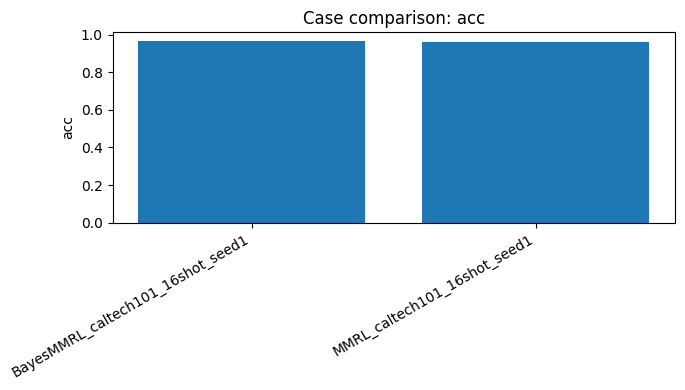

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_acc_main.png


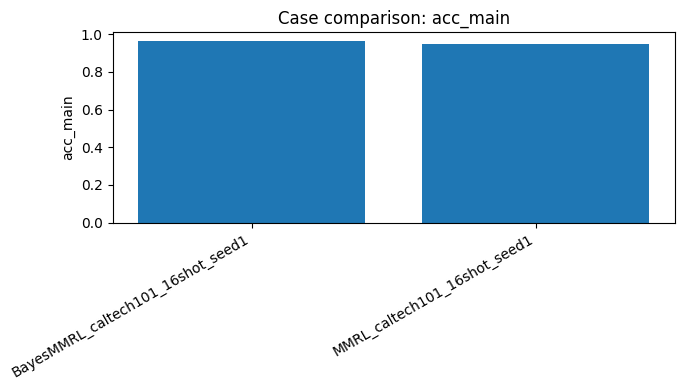

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_acc_rep.png


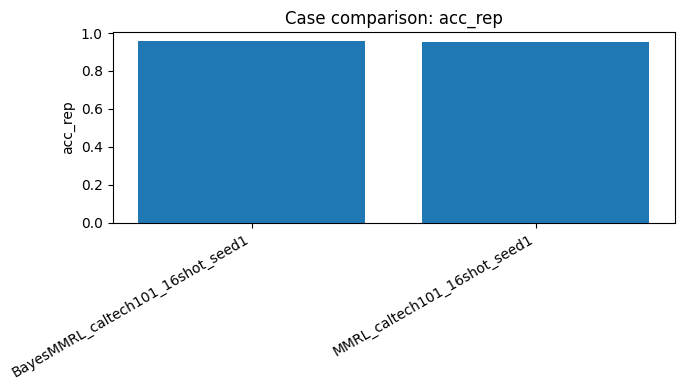

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_mc_acc.png


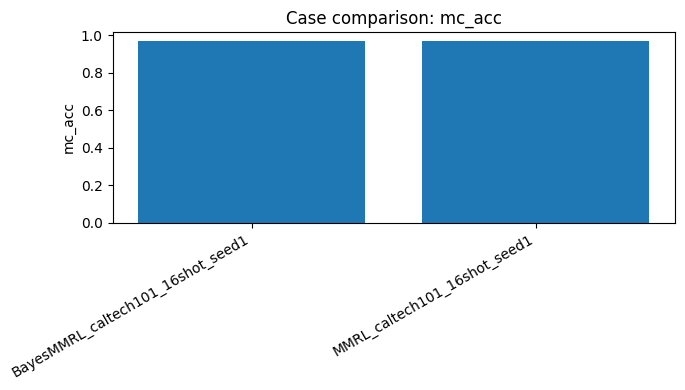

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_nll.png


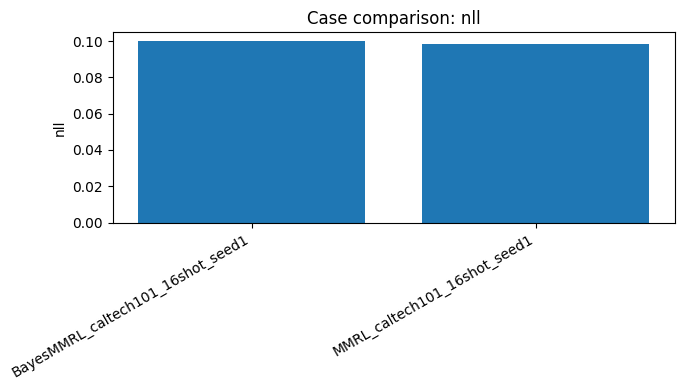

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_brier.png


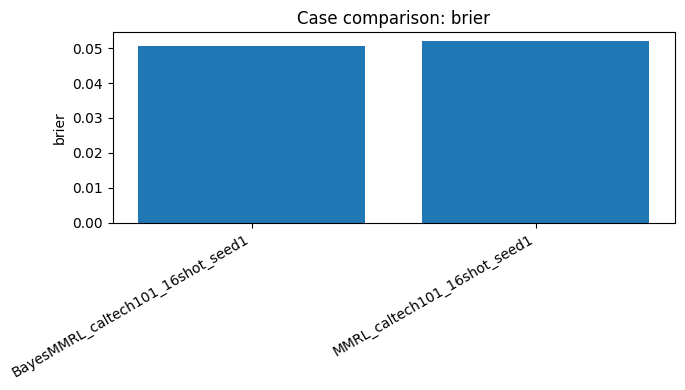

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_ece.png


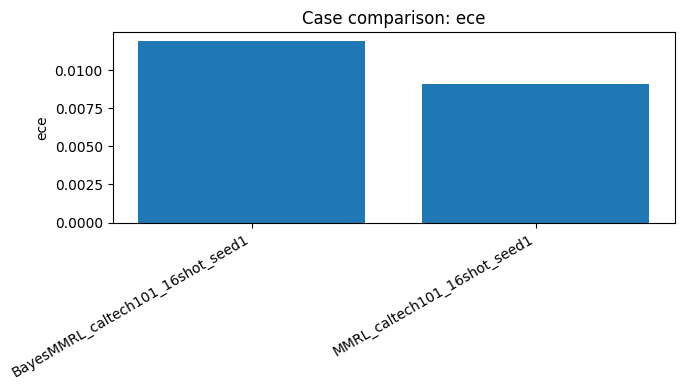

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_entropy.png


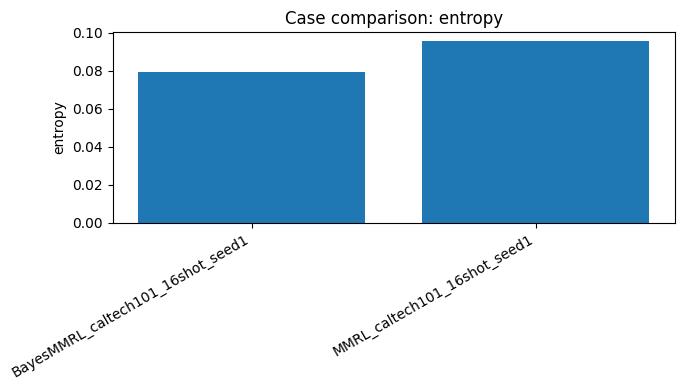

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/metric_bar_js_main_rep.png


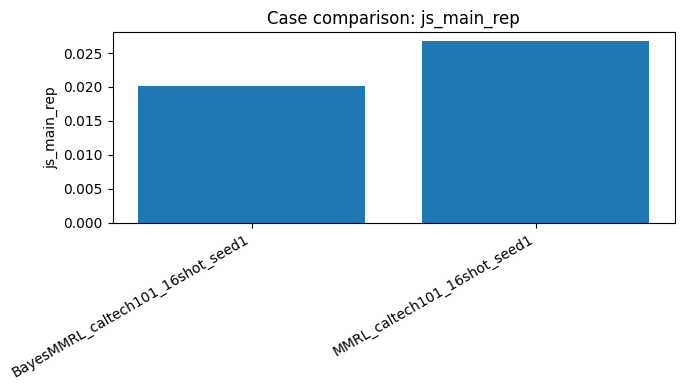

In [11]:

FIG_DIR = SAVE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_current_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("saved:", path)

def plot_metric_bars(summary_df):
    metrics = [c for c in ["acc", "acc_main", "acc_rep", "mc_acc", "nll", "brier", "ece", "entropy", "js_main_rep"] if c in summary_df.columns]
    for m in metrics:
        plt.figure(figsize=(7, 4))
        x = np.arange(len(summary_df))
        vals = summary_df[m].values
        plt.bar(x, vals)
        plt.xticks(x, summary_df["case_name"].values, rotation=30, ha="right")
        plt.ylabel(m)
        plt.title(f"Case comparison: {m}")
        save_current_fig(f"metric_bar_{m}.png")
        plt.show()

plot_metric_bars(summary_df)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_KL.png


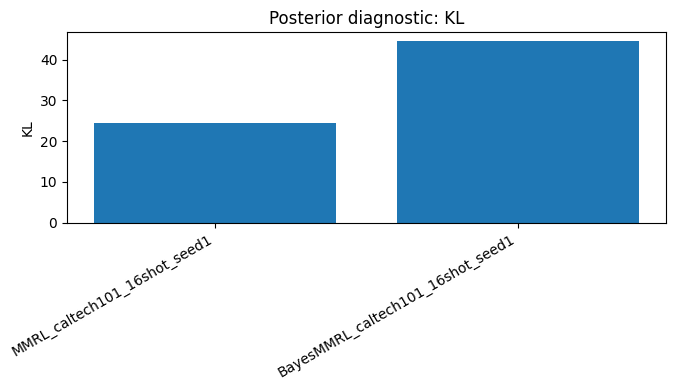

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_posterior_mean_l2.png


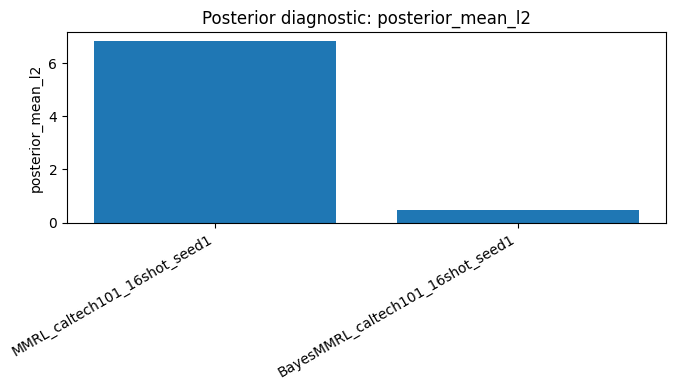

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_posterior_mean_abs_mean.png


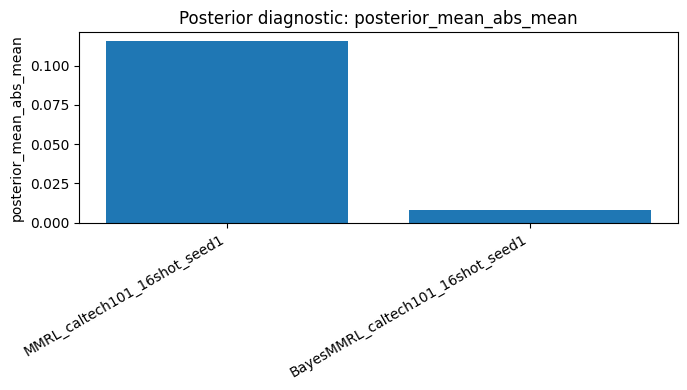

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_prior_mean_l2.png


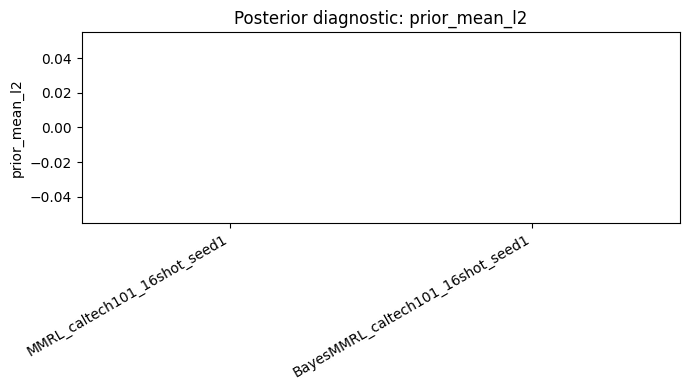

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_prior_mean_abs_mean.png


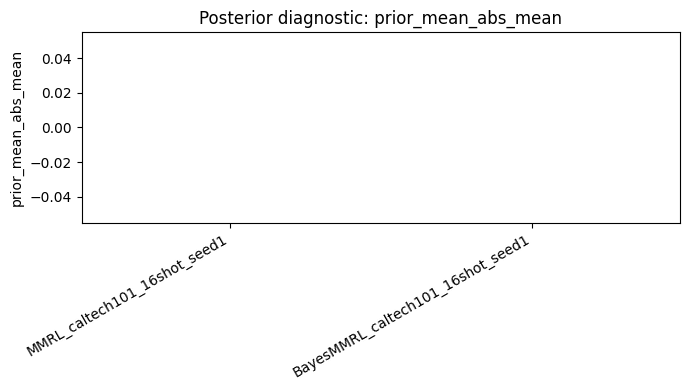

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_mean_shift_l2.png


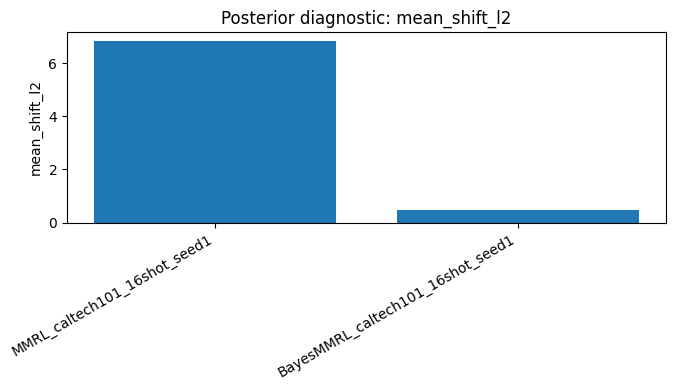

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_mean_shift_abs_mean.png


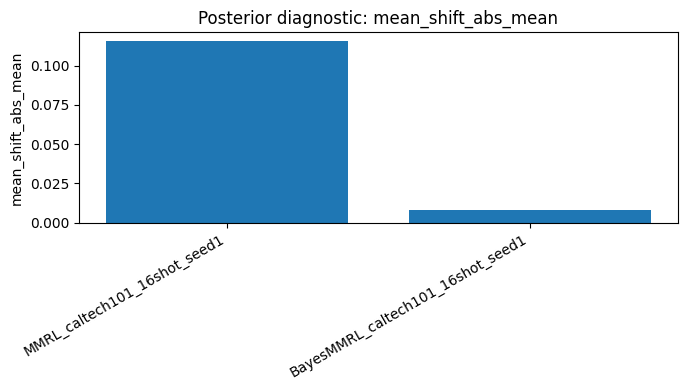

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_sigma_mean.png


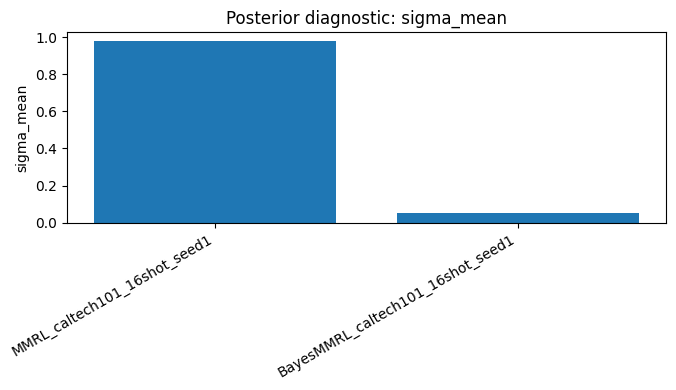

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_sigma_std.png


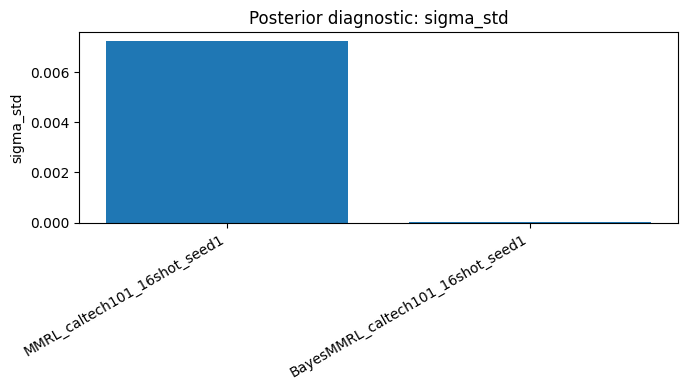

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_sigma_min.png


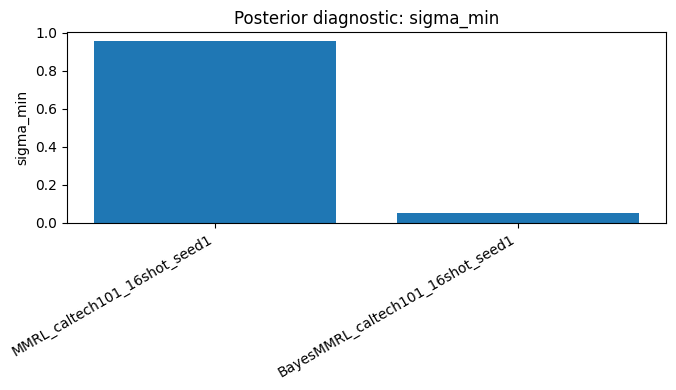

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_sigma_max.png


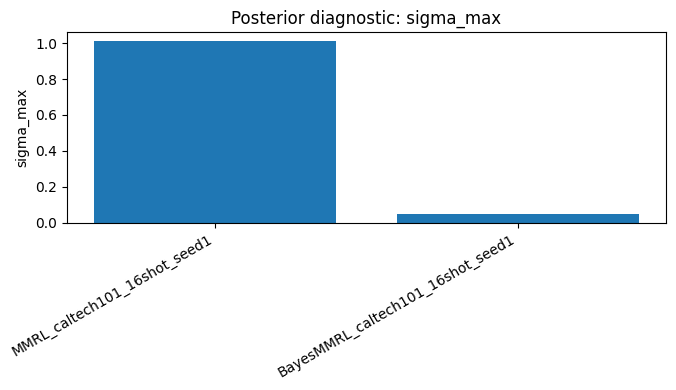

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_sigma_cv.png


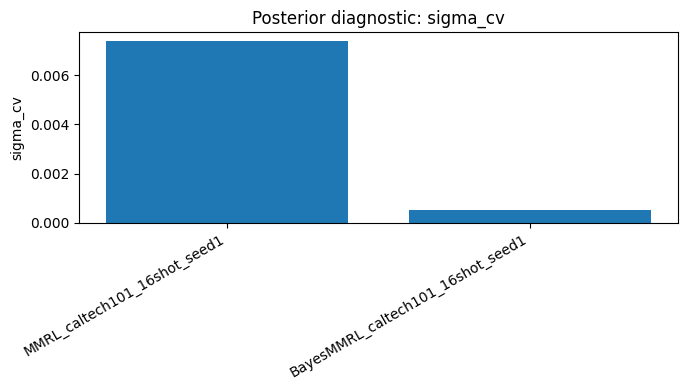

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_SNR_mean.png


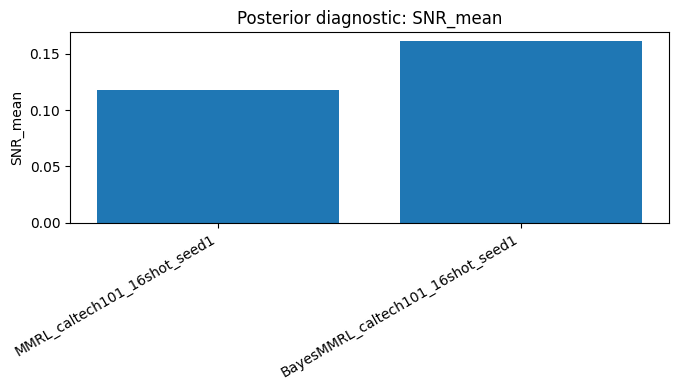

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/posterior_SNR_max.png


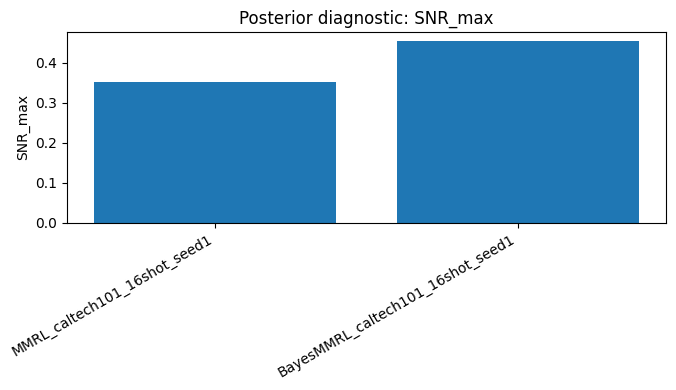

In [12]:

def plot_posterior_diagnostics(posterior_diag_df):
    numeric_cols = [
        "KL", "posterior_mean_l2", "posterior_mean_abs_mean",
        "prior_mean_l2", "prior_mean_abs_mean",
        "mean_shift_l2", "mean_shift_abs_mean",
        "sigma_mean", "sigma_std", "sigma_min", "sigma_max", "sigma_cv",
        "SNR_mean", "SNR_max",
    ]
    for c in numeric_cols:
        if c in posterior_diag_df.columns and posterior_diag_df[c].notna().any():
            plot_df = posterior_diag_df[["case_name", c]].dropna()
            if len(plot_df) == 0:
                continue
            plt.figure(figsize=(7, 4))
            x = np.arange(len(plot_df))
            plt.bar(x, plot_df[c].values)
            plt.xticks(x, plot_df["case_name"].values, rotation=30, ha="right")
            plt.ylabel(c)
            plt.title(f"Posterior diagnostic: {c}")
            save_current_fig(f"posterior_{c}.png")
            plt.show()

plot_posterior_diagnostics(posterior_diag_df)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_conf.png


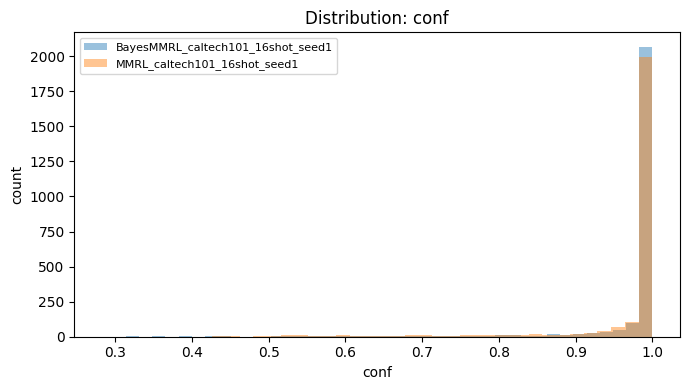

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_margin.png


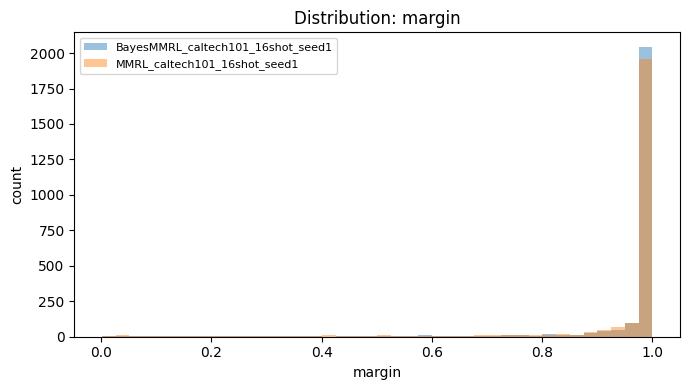

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_entropy.png


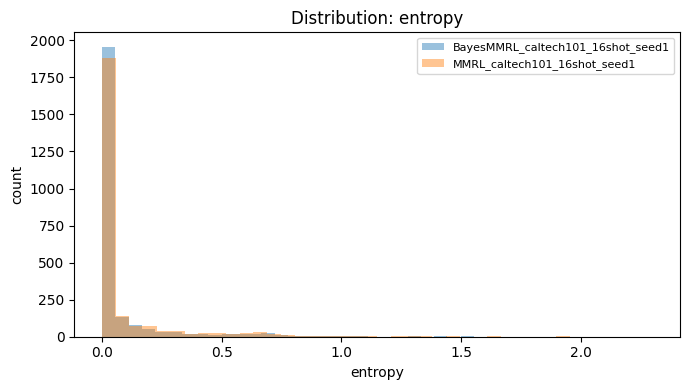

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_nll.png


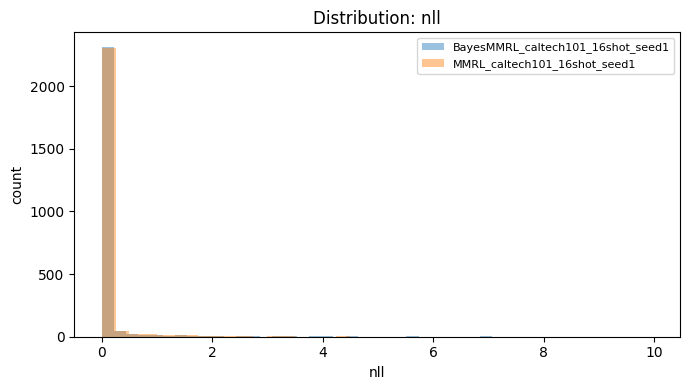

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_brier.png


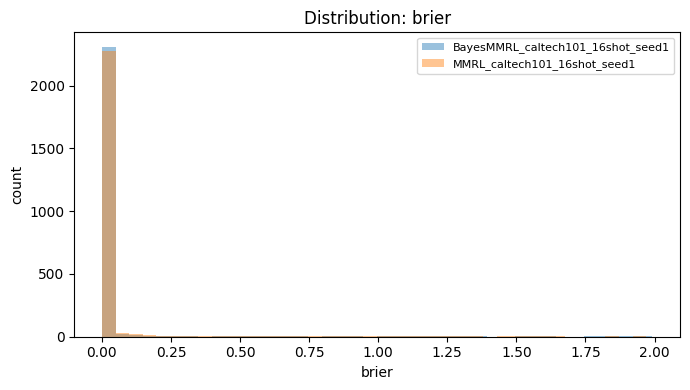

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_js_main_rep.png


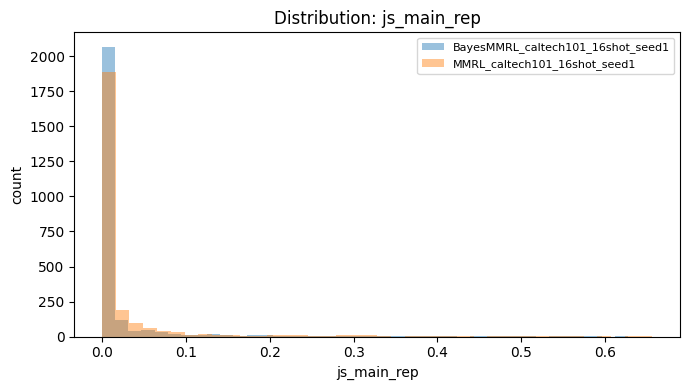

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_symkl_main_rep.png


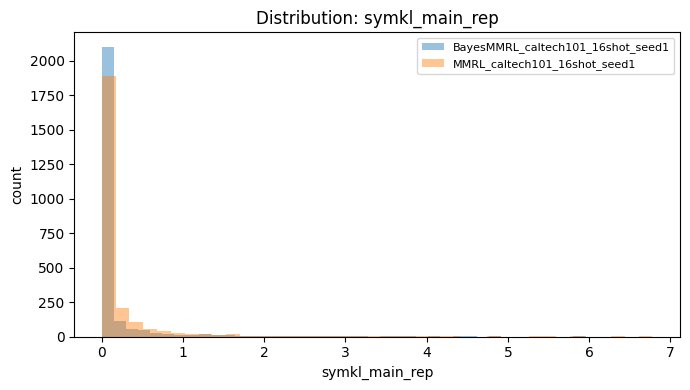

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_predictive_entropy.png


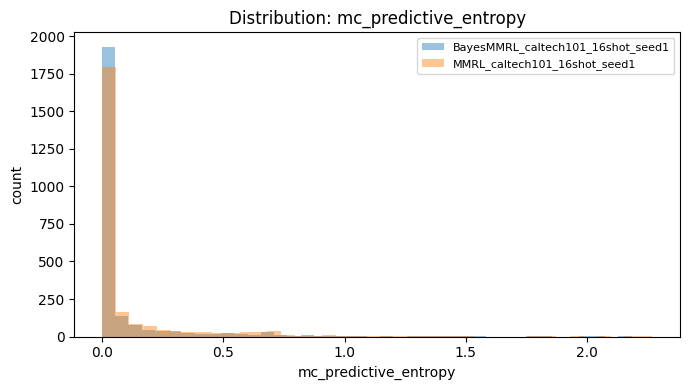

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_expected_entropy.png


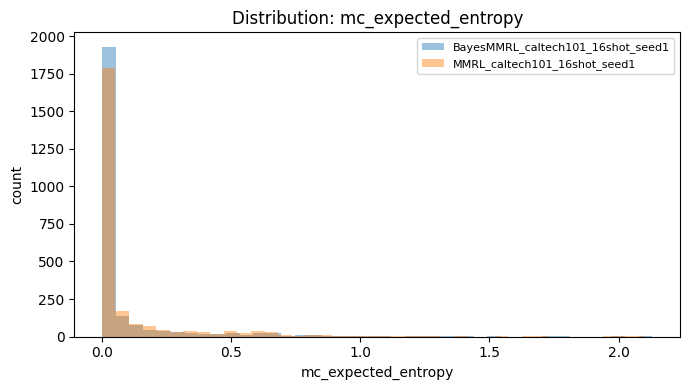

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_mutual_info.png


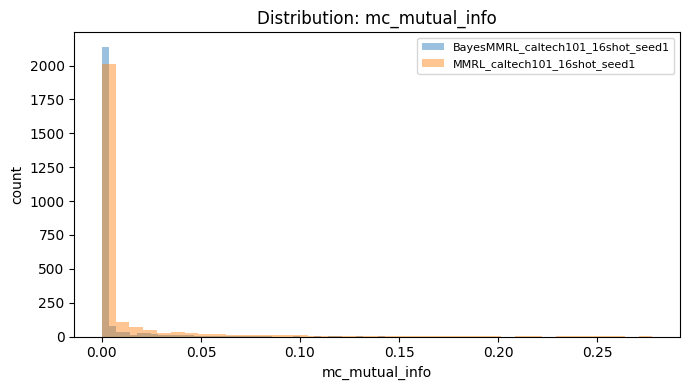

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_variation_ratio.png


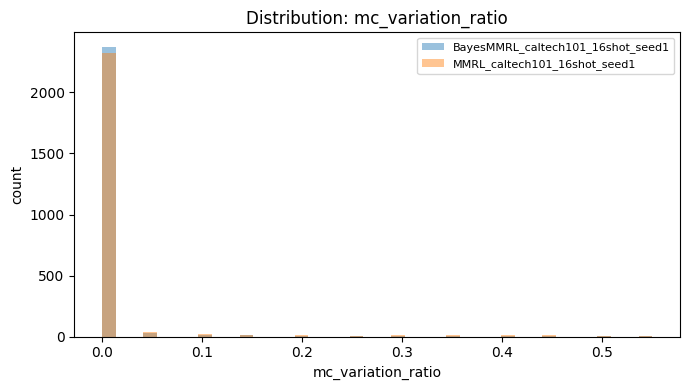

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_sample_agreement.png


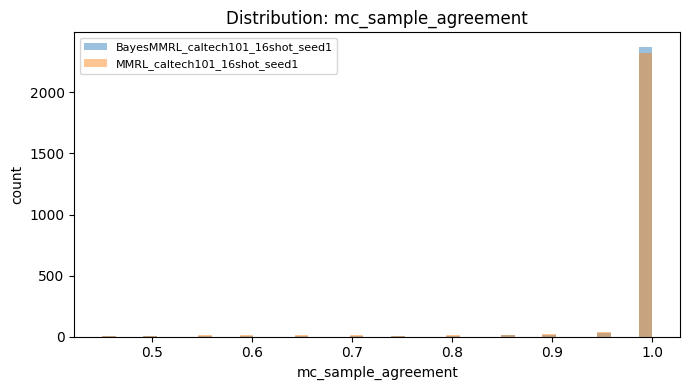

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/hist_mc_vote_entropy.png


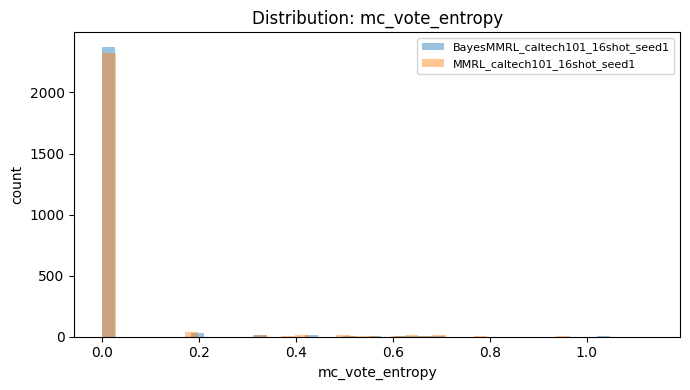

In [13]:

def plot_distributions(outputs_df):
    cols = [c for c in [
        "conf", "margin", "entropy", "nll", "brier",
        "js_main_rep", "symkl_main_rep",
        "mc_predictive_entropy", "mc_expected_entropy", "mc_mutual_info",
        "mc_variation_ratio", "mc_sample_agreement", "mc_vote_entropy"
    ] if c in outputs_df.columns]

    for c in cols:
        plt.figure(figsize=(7, 4))
        for name, g in outputs_df.groupby("case_name"):
            vals = g[c].dropna().values
            if len(vals) == 0:
                continue
            plt.hist(vals, bins=40, alpha=0.45, label=name)
        plt.xlabel(c)
        plt.ylabel("count")
        plt.title(f"Distribution: {c}")
        plt.legend(fontsize=8)
        save_current_fig(f"hist_{c}.png")
        plt.show()

plot_distributions(outputs_df)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_outcome_types.png


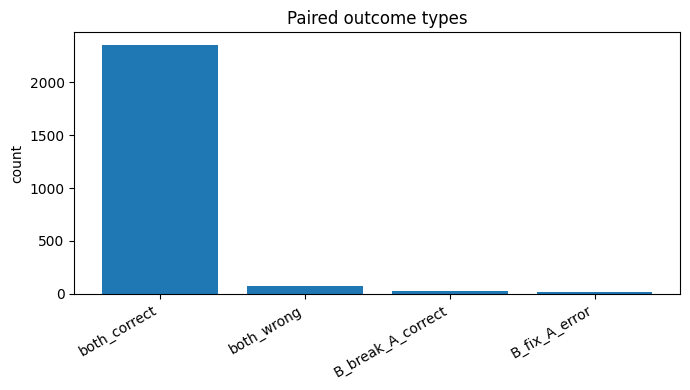

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_delta_conf_B_minus_A.png


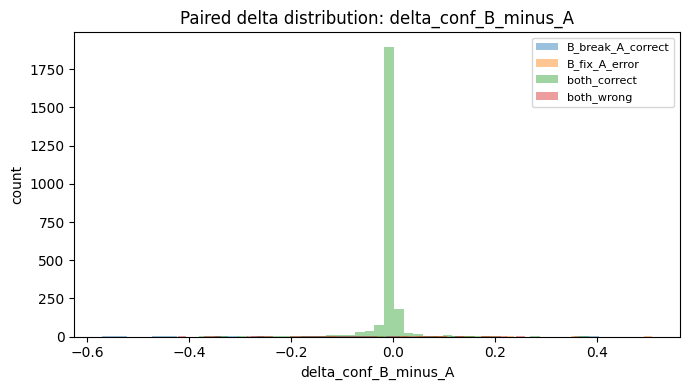

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_delta_margin_B_minus_A.png


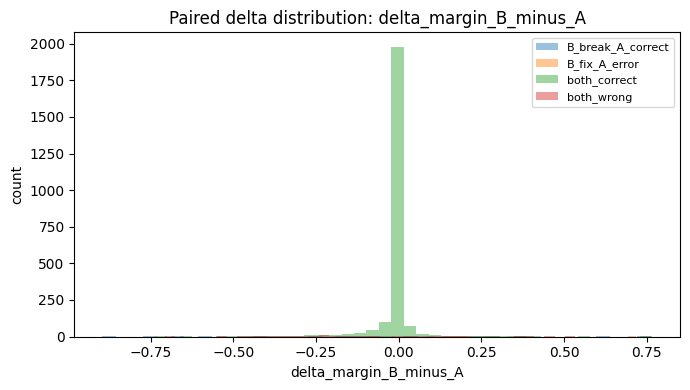

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_delta_entropy_B_minus_A.png


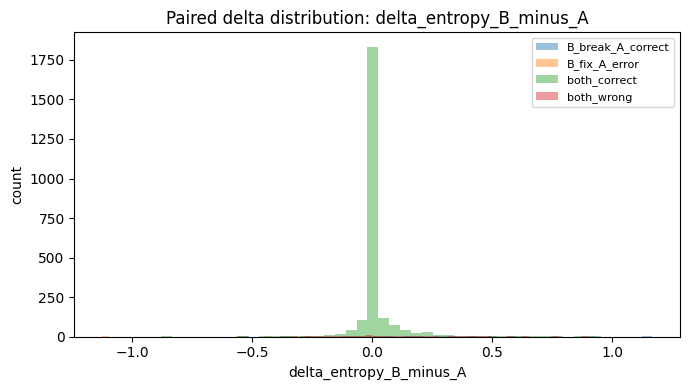

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_delta_nll_B_minus_A.png


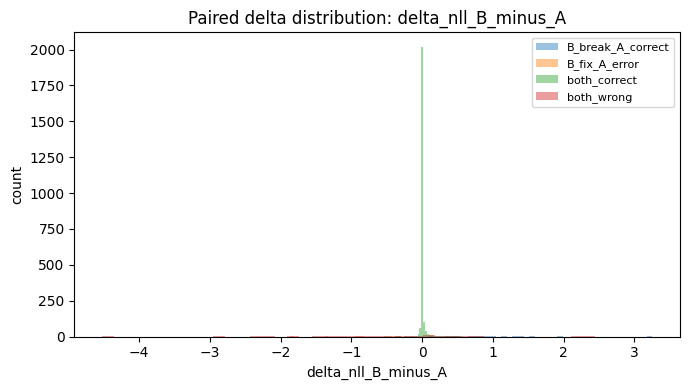

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_delta_js_main_rep_B_minus_A.png


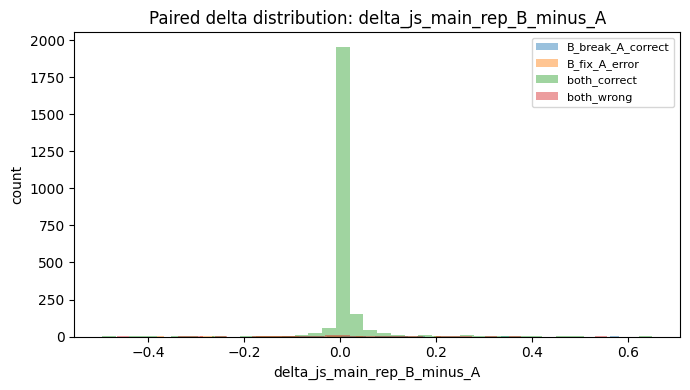

saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/paired_scatter_conf_nll.png


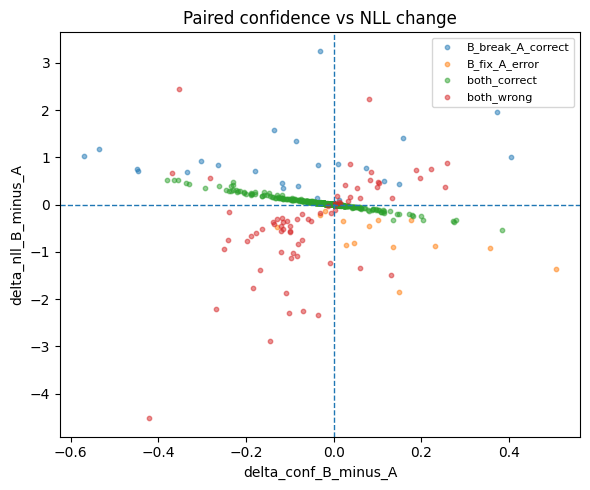

In [14]:

def plot_paired_effects(paired_df):
    if paired_df is None or len(paired_df) == 0:
        print("paired_df is empty")
        return

    vc = paired_df["outcome_type"].value_counts()
    plt.figure(figsize=(7, 4))
    plt.bar(np.arange(len(vc)), vc.values)
    plt.xticks(np.arange(len(vc)), vc.index, rotation=30, ha="right")
    plt.ylabel("count")
    plt.title("Paired outcome types")
    save_current_fig("paired_outcome_types.png")
    plt.show()

    for c in ["delta_conf_B_minus_A", "delta_margin_B_minus_A", "delta_entropy_B_minus_A", "delta_nll_B_minus_A", "delta_js_main_rep_B_minus_A"]:
        if c in paired_df.columns:
            plt.figure(figsize=(7, 4))
            for outcome, g in paired_df.groupby("outcome_type"):
                vals = g[c].dropna().values
                if len(vals):
                    plt.hist(vals, bins=40, alpha=0.45, label=outcome)
            plt.xlabel(c)
            plt.ylabel("count")
            plt.title(f"Paired delta distribution: {c}")
            plt.legend(fontsize=8)
            save_current_fig(f"paired_{c}.png")
            plt.show()

    if "delta_conf_B_minus_A" in paired_df.columns and "delta_nll_B_minus_A" in paired_df.columns:
        plt.figure(figsize=(6, 5))
        for outcome, g in paired_df.groupby("outcome_type"):
            plt.scatter(g["delta_conf_B_minus_A"], g["delta_nll_B_minus_A"], s=10, alpha=0.5, label=outcome)
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.xlabel("delta_conf_B_minus_A")
        plt.ylabel("delta_nll_B_minus_A")
        plt.title("Paired confidence vs NLL change")
        plt.legend(fontsize=8)
        save_current_fig("paired_scatter_conf_nll.png")
        plt.show()

plot_paired_effects(paired_df)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/box_mc_mutual_info_correctness.png


/tmp/ipykernel_73766/2848180721.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


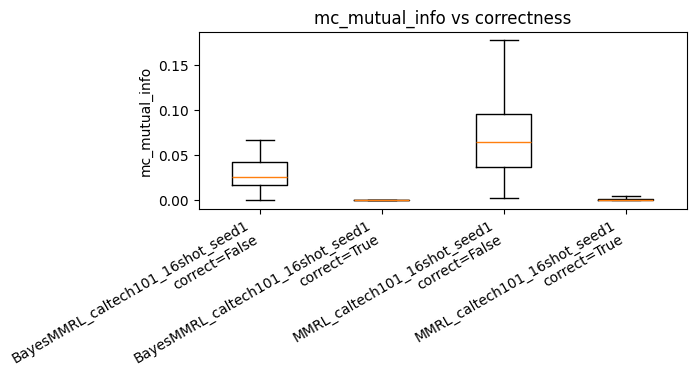

/tmp/ipykernel_73766/2848180721.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/box_mc_variation_ratio_correctness.png


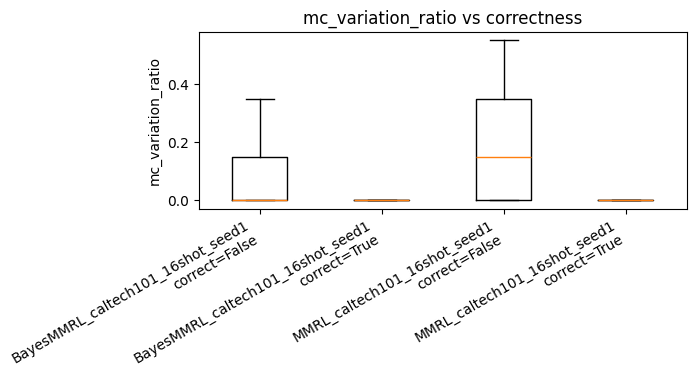

/tmp/ipykernel_73766/2848180721.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/box_mc_predictive_entropy_correctness.png


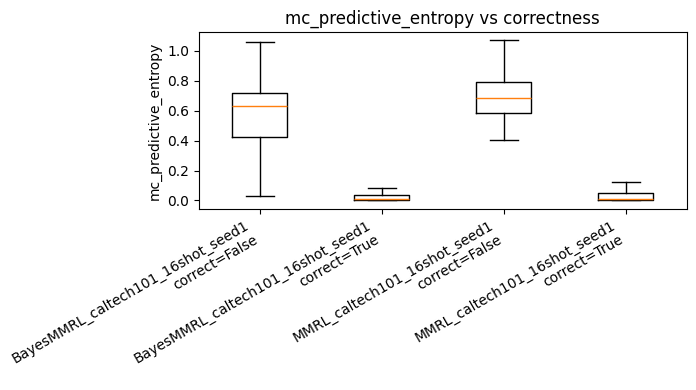

/tmp/ipykernel_73766/2848180721.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/box_entropy_correctness.png


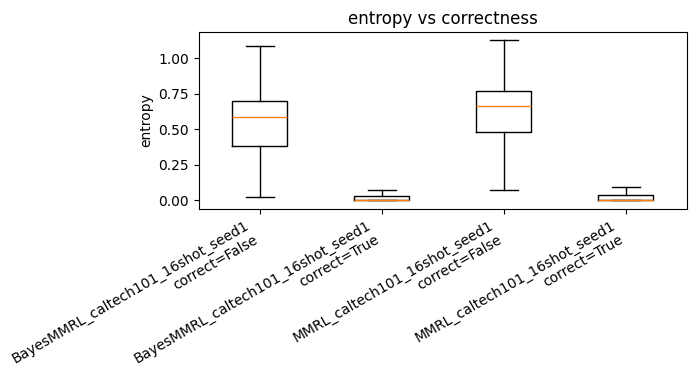

/tmp/ipykernel_73766/2848180721.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


saved: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures/box_js_main_rep_correctness.png


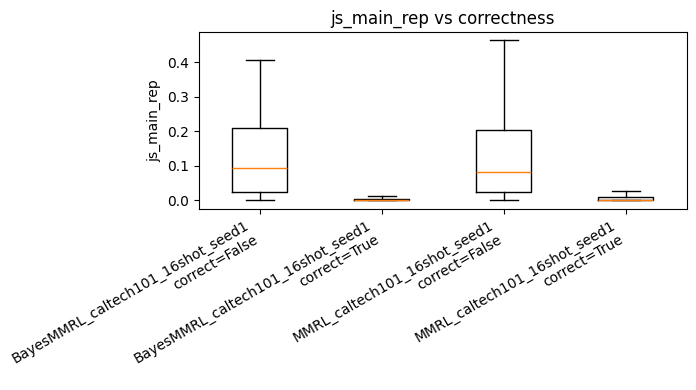

In [15]:

def plot_uncertainty_correctness(outputs_df):
    cols = [c for c in ["mc_mutual_info", "mc_variation_ratio", "mc_predictive_entropy", "entropy", "js_main_rep"] if c in outputs_df.columns]
    for c in cols:
        if not outputs_df[c].notna().any():
            continue
        plt.figure(figsize=(7, 4))
        data = []
        labels = []
        for name, g in outputs_df.groupby("case_name"):
            for corr_val in [False, True]:
                vals = g.loc[g["correct"].eq(corr_val), c].dropna().values
                if len(vals):
                    data.append(vals)
                    labels.append(f"{name}\ncorrect={corr_val}")
        if data:
            plt.boxplot(data, labels=labels, showfliers=False)
            plt.xticks(rotation=30, ha="right")
            plt.ylabel(c)
            plt.title(f"{c} vs correctness")
            save_current_fig(f"box_{c}_correctness.png")
            plt.show()

plot_uncertainty_correctness(outputs_df)


## 10. 保存所有结果

In [16]:

# 保存主要结果
audit_cfg_df.to_csv(SAVE_DIR / "audit_cfg.csv", index=False)
audit_keys_df.to_csv(SAVE_DIR / "audit_state_dict_bayes_keys.csv", index=False)
posterior_diag_df.to_csv(SAVE_DIR / "posterior_diagnostics.csv", index=False)
outputs_df.to_csv(SAVE_DIR / f"sample_outputs_{SPLIT}.csv", index=False)
summary_df.to_csv(SAVE_DIR / f"summary_metrics_{SPLIT}.csv", index=False)
if 'paired_df' in globals() and len(paired_df):
    paired_df.to_csv(SAVE_DIR / f"paired_outcomes_{SPLIT}.csv", index=False)

print("Saved outputs to:", SAVE_DIR)
print("Saved figures to:", FIG_DIR)


Saved outputs to: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2
Saved figures to: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/figures



## 11. 汇总分析报告

这个 cell 会把前面生成的审计、指标、paired outcome 和 posterior 结果整合成一个总览文件，保存到：

```text
SAVE_DIR / mechanism_summary_<split>.md
SAVE_DIR / mechanism_summary_<split>.html
```

它不会重新跑模型，只读取当前 notebook 中已经生成的：

- `audit_cfg_df`
- `posterior_diag_df`
- `summary_df`
- `paired_df`
- `outputs_df`


In [17]:

# ============================================================
# 11. 汇总分析报告：保存 Markdown + HTML
# ============================================================

from datetime import datetime
import html

def _fmt_value(x, ndigits=4):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
    except Exception:
        pass
    if isinstance(x, (float, np.floating)):
        return f"{float(x):.{ndigits}f}"
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    return str(x)

def _df_to_md(df, max_rows=30):
    if df is None or len(df) == 0:
        return "_No rows._"
    show = df.head(max_rows).copy()
    try:
        return show.to_markdown(index=False)
    except Exception:
        return show.to_string(index=False)

def _series_table_md(s, name_col="item", value_col="count"):
    if s is None or len(s) == 0:
        return "_No rows._"
    df = s.rename_axis(name_col).reset_index(name=value_col)
    return _df_to_md(df)

def _top_numeric_deltas(paired_df, max_items=20):
    if paired_df is None or len(paired_df) == 0:
        return pd.DataFrame()
    cols = [c for c in paired_df.columns if c.startswith("delta_")]
    rows = []
    for c in cols:
        vals = paired_df[c]
        if not pd.api.types.is_numeric_dtype(vals):
            continue
        rows.append({
            "delta_metric": c,
            "mean": vals.mean(),
            "median": vals.median(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("mean", key=lambda x: x.abs(), ascending=False).head(max_items)

def _summarize_case_metrics(summary_df):
    if summary_df is None or len(summary_df) == 0:
        return []
    lines = []
    metric_cols = [
        "acc", "mc_acc", "nll", "brier", "ece", "conf", "entropy",
        "margin", "js_main_rep", "symkl_main_rep",
        "mc_mutual_info", "mc_variation_ratio", "mc_sample_agreement"
    ]
    for _, row in summary_df.iterrows():
        name = row.get("case_name", "unknown")
        method = row.get("method", "unknown")
        parts = []
        for c in metric_cols:
            if c in summary_df.columns:
                v = row.get(c, None)
                if v is not None and not pd.isna(v):
                    parts.append(f"{c}={_fmt_value(v)}")
        lines.append(f"- **{name}** (`{method}`): " + ", ".join(parts))
    return lines

def _summarize_posterior(posterior_diag_df):
    if posterior_diag_df is None or len(posterior_diag_df) == 0:
        return []
    lines = []
    cols = [
        "bayes_target", "block_class", "KL", "mean_shift_l2",
        "mean_shift_abs_mean", "sigma_mean", "sigma_std", "sigma_cv",
        "SNR_mean", "SNR_max"
    ]
    for _, row in posterior_diag_df.iterrows():
        name = row.get("case_name", "unknown")
        err = row.get("error", None) if "error" in posterior_diag_df.columns else None
        if err is not None and not pd.isna(err):
            lines.append(f"- **{name}**: {err}")
            continue
        parts = []
        for c in cols:
            if c in posterior_diag_df.columns:
                v = row.get(c, None)
                if v is not None and not pd.isna(v):
                    parts.append(f"{c}={_fmt_value(v)}")
        lines.append(f"- **{name}**: " + ", ".join(parts))
    return lines

def _paired_interpretation_lines(paired_df):
    if paired_df is None or len(paired_df) == 0:
        return ["- 未生成 paired_df；可能只有一个 case，或两个 case 样本数/顺序无法配对。"]

    lines = []
    n = len(paired_df)
    vc = paired_df["outcome_type"].value_counts() if "outcome_type" in paired_df.columns else pd.Series(dtype=int)

    fix = int(vc.get("B_fix_A_error", 0))
    brk = int(vc.get("B_break_A_correct", 0))
    both_correct = int(vc.get("both_correct", 0))
    both_wrong = int(vc.get("both_wrong", 0))

    lines.append(f"- Paired samples: **{n}**")
    lines.append(f"- B fixes A errors: **{fix}** ({fix / max(n, 1):.2%})")
    lines.append(f"- B breaks A correct predictions: **{brk}** ({brk / max(n, 1):.2%})")
    lines.append(f"- Both correct: **{both_correct}** ({both_correct / max(n, 1):.2%})")
    lines.append(f"- Both wrong: **{both_wrong}** ({both_wrong / max(n, 1):.2%})")

    if fix > brk:
        lines.append("- 初步 paired 结论：B 相对 A 的净修复数为正。")
    elif fix < brk:
        lines.append("- 初步 paired 结论：B 相对 A 的净破坏数更多，需要检查不确定性/分支差异是否导致退化。")
    else:
        lines.append("- 初步 paired 结论：B 修复和破坏数量相当，需要结合 NLL、ECE、uncertainty 和 branch divergence 判断。")

    return lines

def _compare_summary_metrics(summary_df):
    if summary_df is None or len(summary_df) < 2:
        return pd.DataFrame()

    a = summary_df.iloc[0]
    b = summary_df.iloc[1]
    metrics = [
        "acc", "mc_acc", "nll", "brier", "ece", "conf", "entropy",
        "margin", "js_main_rep", "symkl_main_rep",
        "mc_mutual_info", "mc_variation_ratio", "mc_sample_agreement"
    ]
    rows = []
    for m in metrics:
        if m in summary_df.columns:
            av = a.get(m, np.nan)
            bv = b.get(m, np.nan)
            if pd.notna(av) and pd.notna(bv):
                rows.append({
                    "metric": m,
                    "A_case": a.get("case_name", "A"),
                    "A_value": av,
                    "B_case": b.get("case_name", "B"),
                    "B_value": bv,
                    "B_minus_A": bv - av,
                })
    return pd.DataFrame(rows)

def make_summary_analysis_report(
    save_dir=SAVE_DIR,
    split=SPLIT,
    audit_cfg_df=None,
    posterior_diag_df=None,
    summary_df=None,
    paired_df=None,
    outputs_df=None,
):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    lines = []
    lines.append("# BayesMMRL Mechanism Diagnosis 汇总分析报告")
    lines.append("")
    lines.append(f"- Generated at: `{timestamp}`")
    lines.append(f"- Split: `{split}`")
    lines.append(f"- Save dir: `{save_dir}`")
    lines.append("")

    lines.append("## 1. 运行与配置审计")
    lines.append("")
    if audit_cfg_df is not None and len(audit_cfg_df):
        keep_cols = [
            "case_name", "method", "method_from_path", "dataset", "shots", "seed",
            "protocol", "phase", "tag", "output_family",
            "cfg.TRAINER.NAME", "cfg.METHOD.NAME", "cfg.MODEL.BACKBONE.NAME",
            "BAYES_TARGET", "N_MC_TEST", "EVAL_MODE", "EVAL_AGGREGATION",
            "REP_SIGMA_MODE", "REP_PRIOR_MODE", "REP_PRIOR_STD", "REP_KL_WEIGHT",
            "REP_LAYERS"
        ]
        keep_cols = [c for c in keep_cols if c in audit_cfg_df.columns]
        lines.append(_df_to_md(audit_cfg_df[keep_cols], max_rows=20))
    else:
        lines.append("_audit_cfg_df not available._")
    lines.append("")

    lines.append("## 2. 总体指标")
    lines.append("")
    for line in _summarize_case_metrics(summary_df):
        lines.append(line)
    lines.append("")
    if summary_df is not None and len(summary_df):
        lines.append(_df_to_md(summary_df, max_rows=20))
    else:
        lines.append("_summary_df not available._")
    lines.append("")

    cmp_df = _compare_summary_metrics(summary_df)
    if len(cmp_df):
        lines.append("### 2.1 Case 间指标差异")
        lines.append("")
        lines.append(_df_to_md(cmp_df, max_rows=40))
        lines.append("")

    lines.append("## 3. Posterior / Bayesian block 诊断")
    lines.append("")
    for line in _summarize_posterior(posterior_diag_df):
        lines.append(line)
    lines.append("")
    if posterior_diag_df is not None and len(posterior_diag_df):
        keep_cols = [
            "case_name", "bayes_target", "block_class", "KL",
            "posterior_mean_shape", "prior_mean_shape", "posterior_sigma_shape",
            "mean_shift_l2", "mean_shift_abs_mean", "sigma_mean", "sigma_std",
            "sigma_cv", "SNR_mean", "SNR_max"
        ]
        keep_cols = [c for c in keep_cols if c in posterior_diag_df.columns]
        lines.append(_df_to_md(posterior_diag_df[keep_cols], max_rows=20))
    else:
        lines.append("_posterior_diag_df not available._")
    lines.append("")

    lines.append("## 4. Paired outcome 分析")
    lines.append("")
    for line in _paired_interpretation_lines(paired_df):
        lines.append(line)
    lines.append("")

    if paired_df is not None and len(paired_df) and "outcome_type" in paired_df.columns:
        lines.append("### 4.1 Outcome counts")
        lines.append("")
        lines.append(_series_table_md(paired_df["outcome_type"].value_counts(), "outcome_type", "count"))
        lines.append("")

        delta_df = _top_numeric_deltas(paired_df)
        if len(delta_df):
            lines.append("### 4.2 Top paired delta metrics")
            lines.append("")
            lines.append(_df_to_md(delta_df, max_rows=30))
            lines.append("")

    lines.append("## 5. 样本级输出概览")
    lines.append("")
    if outputs_df is not None and len(outputs_df):
        lines.append(f"- Total sample rows: **{len(outputs_df)}**")
        lines.append(f"- Cases: `{list(outputs_df['case_name'].unique())}`")
        if "correct" in outputs_df.columns:
            lines.append("")
            lines.append("### 5.1 Correctness by case")
            lines.append("")
            corr_tab = outputs_df.groupby("case_name")["correct"].agg(["count", "mean"]).reset_index()
            corr_tab = corr_tab.rename(columns={"mean": "accuracy"})
            lines.append(_df_to_md(corr_tab, max_rows=20))
    else:
        lines.append("_outputs_df not available._")
    lines.append("")

    lines.append("## 6. 文件输出")
    lines.append("")
    expected_files = [
        "audit_cfg.csv",
        "audit_state_dict_bayes_keys.csv",
        "posterior_diagnostics.csv",
        f"sample_outputs_{split}.csv",
        f"summary_metrics_{split}.csv",
        f"paired_outcomes_{split}.csv",
        f"mechanism_summary_{split}.md",
        f"mechanism_summary_{split}.html",
    ]
    for fn in expected_files:
        p = save_dir / fn
        status = "exists" if p.exists() else "will be generated / missing"
        lines.append(f"- `{fn}`: {status}")
    lines.append("")

    report_md = "\n".join(lines)

    md_path = save_dir / f"mechanism_summary_{split}.md"
    html_path = save_dir / f"mechanism_summary_{split}.html"

    md_path.write_text(report_md, encoding="utf-8")

    try:
        import markdown
        html_body = markdown.markdown(report_md, extensions=["tables"])
    except Exception:
        html_body = "<pre>" + html.escape(report_md) + "</pre>"

    html_doc = f"""<!doctype html>
<html>
<head>
<meta charset="utf-8">
<title>BayesMMRL Mechanism Summary</title>
<style>
body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; margin: 32px; line-height: 1.55; }}
table {{ border-collapse: collapse; margin: 12px 0; font-size: 13px; }}
th, td {{ border: 1px solid #ddd; padding: 6px 8px; }}
th {{ background: #f6f6f6; }}
code {{ background: #f4f4f4; padding: 2px 4px; }}
pre {{ background: #f8f8f8; padding: 16px; overflow-x: auto; }}
</style>
</head>
<body>
{html_body}
</body>
</html>
"""
    html_path.write_text(html_doc, encoding="utf-8")

    print("saved summary markdown:", md_path)
    print("saved summary html    :", html_path)

    return report_md, md_path, html_path

report_md, report_md_path, report_html_path = make_summary_analysis_report(
    save_dir=SAVE_DIR,
    split=SPLIT,
    audit_cfg_df=audit_cfg_df if "audit_cfg_df" in globals() else None,
    posterior_diag_df=posterior_diag_df if "posterior_diag_df" in globals() else None,
    summary_df=summary_df if "summary_df" in globals() else None,
    paired_df=paired_df if "paired_df" in globals() else None,
    outputs_df=outputs_df if "outputs_df" in globals() else None,
)

print("\n===== REPORT PREVIEW =====")
print("\n".join(report_md.splitlines()[:80]))


saved summary markdown: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/mechanism_summary_test.md
saved summary html    : /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/mechanism_summary_test.html

===== REPORT PREVIEW =====
# BayesMMRL Mechanism Diagnosis 汇总分析报告

- Generated at: `2026-04-26 14:53:01`
- Split: `test`
- Save dir: `/root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2`

## 1. 运行与配置审计

| case_name                         | method    | method_from_path   | dataset    |   shots |   seed | protocol   | phase         | tag                                    | output_family   | cfg.TRAINER.NAME   | cfg.METHOD.NAME   | cfg.MODEL.BACKBONE.NAME   | BAYES_TARGET   |   N_MC_TEST | EVAL_MODE     | EVAL_AGGREGATION   | REP_SIGMA_MODE   | REP_PRIOR_MODE   |   REP_PRIOR_STD |   REP_KL_WEIGHT | REP_LAYERS               |
|:----------------------------------|:----------|:-------------------|:-----------|--------:|-------:|:-----------|:------------